# Sistema RAG Completo com Avaliação de Qualidade

## Prática 02 - Implementação Didática de RAG com Métricas

**Autor:** Jefferson Cunha  - jwc@
**Contexto:** Doutorado Profissional em Engenharia de Software - Discp. NLP
**Objetivo:** Implementar um sistema RAG (Retrieval-Augmented Generation) completo utilizando dados reais do HuggingFace, com foco em avaliação de qualidade através de métricas estabelecidas pela literatura.

---

## Visão Geral do Projeto

Este notebook implementa um sistema RAG end-to-end, desde a ingestão de dados até a avaliação com métricas rigorosas. O projeto é **didático e reprodutível**, priorizando a clareza conceitual sobre otimizações de produção.

### Por que RAG é importante?

Em domínios especializados como medicina e ciência, os LLMs generalistas enfrentam dois problemas críticos:

1. **Conhecimento desatualizado:** Modelos são treinados em dados históricos e não conhecem informações recentes
2. **Alucinações:** Tendem a gerar respostas plausíveis mas incorretas quando não possuem conhecimento factual

**RAG resolve esses problemas** ao combinar:
- **Retrieval:** Busca semântica em base de conhecimento atualizada
- **Augmentation:** Injeção do conhecimento recuperado no contexto do LLM
- **Generation:** Geração de resposta fundamentada nas evidências fornecidas

### Arquitetura do Sistema

```
┌─────────────┐
│   Query     │ "What is the role of p53 in cancer?"
└──────┬──────┘
       │
       ▼
┌─────────────────────────────────────────────────┐
│  1. INDEXAÇÃO (Offline)                         │
│  ┌──────────────┐   ┌──────────────┐            │
│  │ Documents    │──▶│  Chunking    │            │
│  │ Pool (740MB) │   │ (Overlap)    │            │
│  └──────────────┘   └──────┬───────┘            │
│                            │                     │
│                            ▼                     │
│                     ┌──────────────┐             │
│                     │  Embeddings  │             │
│                     │ (OpenAI API) │             │
│                     └──────┬───────┘             │
│                            │                     │
│                            ▼                     │
│                     ┌──────────────┐             │
│                     │  Vector DB   │             │
│                     │  (ChromaDB)  │             │
│                     └──────────────┘             │
└─────────────────────────────────────────────────┘
       │
       ▼
┌─────────────────────────────────────────────────┐
│  2. RETRIEVAL (Online)                          │
│                                                  │
│  Query Embedding ──▶ Similarity Search ──▶ Top-K│
│                      (Cosine Distance)    Docs  │
└────────────────────────────┬────────────────────┘
                             │
                             ▼
┌─────────────────────────────────────────────────┐
│  3. GENERATION                                  │
│                                                  │
│  ┌────────────┐   ┌────────────┐   ┌─────────┐ │
│  │   Query    │ + │ Retrieved  │──▶│   LLM   │ │
│  │            │   │  Context   │   │ (GPT-4) │ │
│  └────────────┘   └────────────┘   └────┬────┘ │
│                                         │       │
│                                         ▼       │
│                                    ┌─────────┐  │
│                                    │ Answer  │  │
│                                    └─────────┘  │
└─────────────────────────────────────────────────┘
       │
       ▼
┌─────────────────────────────────────────────────┐
│  4. AVALIAÇÃO                                   │
│                                                  │
│  ┌─────────────────┐  ┌──────────────────────┐ │
│  │ LLM Metrics     │  │ Retrieval Metrics    │ │
│  │ - Correctness   │  │ - Precision@K        │ │
│  │ - Faithfulness  │  │ - Recall@K           │ │
│  │                 │  │ - Contextual Metrics │ │
│  └─────────────────┘  └──────────────────────┘ │
└─────────────────────────────────────────────────┘
```

### Dataset: AQ-MedAI/RAG-QA-Leaderboard

Utilizaremos dados médicos/científicos do PubMed com estrutura completa para avaliação:

- **Queries:** Perguntas médicas/científicas
- **Ground Truth:** Respostas corretas esperadas
- **Golden Documents:** Documentos que contêm evidências para as respostas
- **Document Pool:** Corpus de 740MB com conhecimento da Wikipédia

### Métricas de Avaliação

**Geração (LLM-as-a-judge):**
- **Correctness (Answer Relevancy):** A resposta está completa e relevante?
- **Faithfulness:** A resposta está fundamentada no contexto ou alucinou?

**Recuperação (Information Retrieval):**
- **Precision@K:** Proporção de documentos relevantes recuperados
- **Recall@K:** Cobertura dos documentos golden
- **Contextual Recall/Precision/Relevancy:** Métricas contextuais avançadas

### Ferramentas Utilizadas

- **LangChain:** Orquestração do pipeline RAG
- **ChromaDB:** Vector database local
- **OpenAI:** Embeddings (text-embedding-3-small) e LLM (gpt-4o-mini)
- **DeepEval:** Framework de avaliação com LLM-as-a-judge
- **Langfuse:** Observabilidade e rastreamento de custos/latência

---

## Estrutura deste Notebook

1. **Configuração do Ambiente** - Setup de dependências e credenciais
2. **Aquisição de Dados** - Download e exploração do dataset HuggingFace
3. **Indexação** - Chunking, embeddings e criação do vector database
4. **Retriever** - Implementação de busca semântica
5. **Generator** - Geração de respostas com prompt engineering
6. **Avaliação LLM** - Métricas de correctness e faithfulness
7. **Avaliação IR** - Métricas de recuperação de informação
8. **Observabilidade** - Análise de custos e latência com Langfuse
9. **Casos Extremos** - Testes de edge cases e limitações
10. **Conclusões** - Resultados, aprendizados e próximos passos

---

# 1. Configuração do Ambiente

Nesta seção, configuraremos todas as dependências necessárias e validaremos a conectividade com as APIs externas (OpenAI e Langfuse).

## Dependências do Projeto

- `langchain` + `langchain-openai`: Framework para orquestração de LLMs
- `langchain-community`: Componentes comunitários (ChromaDB integration)
- `chromadb`: Vector database local para armazenamento de embeddings
- `openai`: Cliente oficial da OpenAI para embeddings e chat
- `langfuse`: Plataforma de observabilidade para LLMOps
- `deepeval`: Framework de avaliação com métricas LLM-as-a-judge
- `huggingface_hub`: Download de datasets do HuggingFace
- `pandas`, `matplotlib`, `seaborn`: Análise e visualização de dados
- `python-dotenv`: Gestão segura de variáveis de ambiente

In [41]:
# Instalação de dependências (executar apenas uma vez)
# Descomente as linhas abaixo se precisar instalar os pacotes

# !pip install -q langchain langchain-openai langchain-community
# !pip install -q chromadb openai
# !pip install -q langfuse deepeval
# !pip install -q huggingface_hub datasets
# !pip install -q pandas matplotlib seaborn
# !pip install -q python-dotenv

print("✅ Instalação de dependências configurada. Descomente as linhas acima se necessário.")

✅ Instalação de dependências configurada. Descomente as linhas acima se necessário.


## Configuração de Credenciais

Para executar este notebook, você precisa configurar as seguintes credenciais no arquivo `.env` na raiz do projeto:

```bash
OPENAI_API_KEY="sua-chave-openai"
LANGFUSE_PUBLIC_KEY="sua-chave-publica-langfuse"
LANGFUSE_SECRET_KEY="sua-chave-secreta-langfuse"
LANGFUSE_HOST="https://cloud.langfuse.com"
```

**Como obter as credenciais:**

1. **OpenAI API Key:** 
   - Acesse https://platform.openai.com/api-keys
   - Crie uma nova API key
   - Tenha créditos disponíveis na conta

2. **Langfuse Keys:**
   - Acesse https://cloud.langfuse.com/
   - Crie uma conta gratuita
   - Vá em Settings → API Keys
   - Copie Public Key, Secret Key e Host

Use o arquivo `.env.example` como template.

In [42]:
import os
from dotenv import load_dotenv

# Carrega variáveis de ambiente do arquivo .env
load_dotenv()

# Validação de credenciais
required_vars = [
    "OPENAI_API_KEY",
    "LANGFUSE_PUBLIC_KEY",
    "LANGFUSE_SECRET_KEY",
    "LANGFUSE_HOST"
]

missing_vars = []
for var in required_vars:
    if not os.getenv(var):
        missing_vars.append(var)
        print(f"❌ {var} não configurada")
    else:
        # Mostra apenas os primeiros caracteres para segurança
        value = os.getenv(var)
        if "KEY" in var:
            masked = value[:8] + "..." if len(value) > 8 else "***"
            print(f"✅ {var}: {masked}")
        else:
            print(f"✅ {var}: {value}")

if missing_vars:
    print(f"\n⚠️  ATENÇÃO: {len(missing_vars)} variável(is) faltando no arquivo .env")
    print("Por favor, configure as credenciais antes de prosseguir.")
else:
    print("\n✅ Todas as credenciais configuradas com sucesso!")

✅ OPENAI_API_KEY: sk-proj-...
✅ LANGFUSE_PUBLIC_KEY: pk-lf-11...
✅ LANGFUSE_SECRET_KEY: sk-lf-48...
✅ LANGFUSE_HOST: https://us.cloud.langfuse.com

✅ Todas as credenciais configuradas com sucesso!


## Teste de Conectividade

Vamos validar que conseguimos nos conectar às APIs necessárias.

In [43]:
from openai import OpenAI
from langfuse import get_client

print("🔍 Testando conectividade com APIs...\n")

# Teste OpenAI
try:
    client_openai = OpenAI()
    # Teste simples com embedding
    response = client_openai.embeddings.create(
        model="text-embedding-3-small",
        input="teste de conectividade"
    )
    print(f"✅ OpenAI API: Conectado com sucesso")
    print(f"   Modelo: text-embedding-3-small")
    print(f"   Dimensões do embedding: {len(response.data[0].embedding)}")
except Exception as e:
    print(f"❌ OpenAI API: Falha na conexão")
    print(f"   Erro: {str(e)}")

print()

# Teste Langfuse
try:
    langfuse_client = get_client()
    print(f"✅ Langfuse: Cliente inicializado")
    print(f"   Host: {os.getenv('LANGFUSE_HOST')}")
    print(f"   Status: Pronto para rastreamento")
except Exception as e:
    print(f"❌ Langfuse: Falha na inicialização")
    print(f"   Erro: {str(e)}")

print("\n✅ Testes de conectividade concluídos!")

✅ OpenAI API: Conectado com sucesso
   Modelo: text-embedding-3-small
   Dimensões do embedding: 1536

✅ Langfuse: Cliente inicializado
   Host: https://us.cloud.langfuse.com
   Status: Pronto para rastreamento

✅ Testes de conectividade concluídos!


---

# 2. Aquisição e Exploração de Dados

## Dataset: AQ-MedAI/RAG-QA-Leaderboard

Este dataset foi criado especificamente para avaliação de sistemas RAG e contém:

### Arquivos Principais

1. **pubmed.jsonl** (583 KB)
   - Perguntas e respostas do domínio médico/científico
   - Cada linha contém um objeto JSON com: `id`, `query`, `golden_doc`, `reference`, `ground_truth`
   
2. **documents_pool.json** (740 MB)
   - Corpus centralizado de documentos da Wikipédia
   - Estrutura: `{document_id: {title, text, url}}`
   - Os IDs em `golden_doc` e `reference` referenciam documentos neste pool

### Estrutura dos Dados

**Exemplo de registro em pubmed.jsonl:**
```json
{
  "id": "pubmed_001",
  "query": "What is the role of p53 in cancer?",
  "golden_doc": ["Document_12345", "Document_67890"],
  "reference": ["Document_11111", "Document_22222"],
  "ground_truth": ["p53 is a tumor suppressor..."]
}
```

**Campos:**
- `query`: Pergunta médica/científica
- `golden_doc`: IDs dos documentos "ouro" que contêm evidências para a resposta
- `reference`: IDs de documentos adicionais relacionados
- `ground_truth`: Resposta(s) correta(s) esperada(s)

### Estratégia de Amostragem

Para fins didáticos, trabalharemos com um **subset otimizado**:
1. Carregar todas as queries do pubmed.jsonl
2. Extrair apenas os documentos referenciados (em vez dos 740MB completos)
3. Usar amostra de 50-100 queries para desenvolvimento
4. Manter código escalável para dataset completo

## 2.1. Download dos Dados do HuggingFace

Vamos baixar os arquivos necessários usando a biblioteca `huggingface_hub`.

In [44]:
from huggingface_hub import hf_hub_download
import json
from pathlib import Path

print("📥 Iniciando download dos dados do HuggingFace...\n")

# Configurações
REPO_ID = "AQ-MedAI/RAG-QA-Leaderboard"
CACHE_DIR = "./data"  # Diretório local para cache

# Criar diretório se não existir
Path(CACHE_DIR).mkdir(exist_ok=True)

# Download pubmed.jsonl
print("1️⃣  Baixando pubmed.jsonl...")
try:
    pubmed_path = hf_hub_download(
        repo_id=REPO_ID,
        filename="final_data/pubmed.jsonl",
        repo_type="dataset",
        cache_dir=CACHE_DIR
    )
    print(f"   ✅ pubmed.jsonl baixado: {pubmed_path}")
except Exception as e:
    print(f"   ❌ Erro ao baixar pubmed.jsonl: {e}")
    pubmed_path = None

print()

# Download documents_pool.json
print("2️⃣  Baixando documents_pool.json (740 MB - pode demorar alguns minutos)...")
try:
    docs_pool_path = hf_hub_download(
        repo_id=REPO_ID,
        filename="final_data/documents_pool.json",
        repo_type="dataset",
        cache_dir=CACHE_DIR
    )
    print(f"   ✅ documents_pool.json baixado: {docs_pool_path}")
except Exception as e:
    print(f"   ❌ Erro ao baixar documents_pool.json: {e}")
    docs_pool_path = None

print("\n✅ Download concluído!")

   ✅ pubmed.jsonl baixado: ./data/datasets--AQ-MedAI--RAG-QA-Leaderboard/snapshots/5788a13a8a551f5c4f7ea92f901fe2e924dccb69/final_data/pubmed.jsonl

2️⃣  Baixando documents_pool.json (740 MB - pode demorar alguns minutos)...
   ✅ documents_pool.json baixado: ./data/datasets--AQ-MedAI--RAG-QA-Leaderboard/snapshots/5788a13a8a551f5c4f7ea92f901fe2e924dccb69/final_data/documents_pool.json

✅ Download concluído!


## 2.2. Carregamento e Parsing dos Dados

Vamos carregar os arquivos JSON/JSONL e explorar sua estrutura.

In [45]:
import pandas as pd

print("📊 Carregando e parsing dos dados...\n")

# Carregar pubmed.jsonl (JSON Lines - uma query por linha)
print("1️⃣ Carregando pubmed.jsonl...")
pubmed_queries = []
with open(pubmed_path, 'r', encoding='utf-8') as f:
    for line in f:
        pubmed_queries.append(json.loads(line.strip()))

print(f"   ✅ {len(pubmed_queries)} queries carregadas")

# Mostrar exemplo de query
print("\n📋 Exemplo de query:")
print(json.dumps(pubmed_queries[0], indent=2))

print()

# Carregar documents_pool.json
print("2️⃣ Carregando documents_pool.json (pode demorar um pouco)...")
with open(docs_pool_path, 'r', encoding='utf-8') as f:
    documents_pool = json.load(f)

print(f"   ✅ {len(documents_pool):,} documentos carregados no pool")

# Mostrar exemplo de documento
doc_id = list(documents_pool.keys())[0]
print(f"\n📄 Exemplo de documento (ID: {doc_id}):")
print(json.dumps(documents_pool[doc_id], indent=2)[:200] + "...")

   ✅ 1,089,245 documentos carregados no pool

📄 Exemplo de documento (ID: Document_1):
"title: A Wrong Way to Love\ncontent: A Wrong Way to Love is a 1969 Italian drama film. It was directed by Fernando Di Leo. It stars Nieves Navarro, Gianni Macchia, Micaela Pignatelli, Lucio Dalla, an...


## 2.3. Análise Exploratória dos Dados

Vamos analisar as características do dataset para entender melhor sua estrutura.

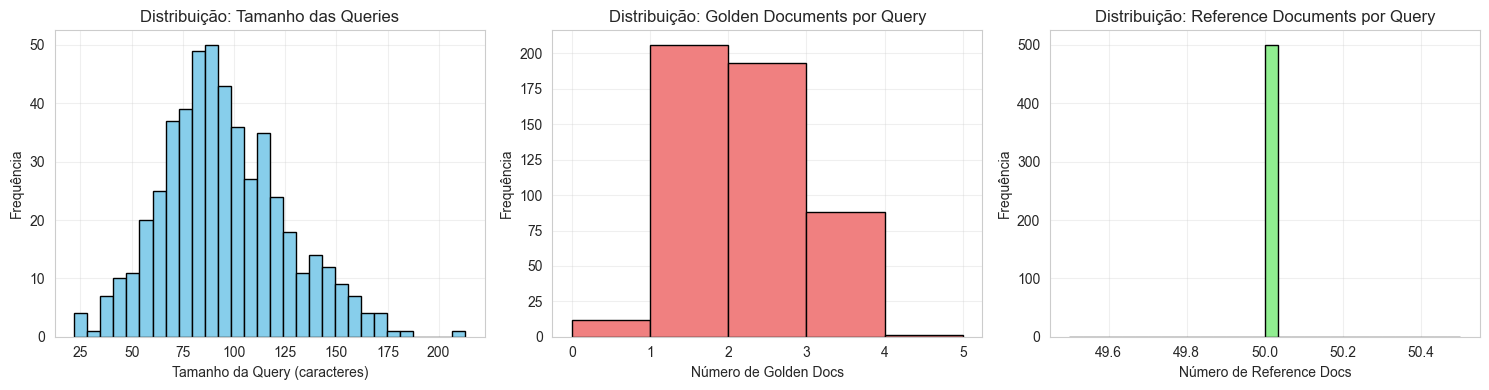

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 4)

# Análise das queries
df_queries = pd.DataFrame(pubmed_queries)

print("="*80)
print("ANÁLISE DO DATASET PUBMED")
print("="*80)

print(f"\n📊 Estatísticas Gerais:")
print(f"   Total de queries: {len(df_queries)}")
print(f"   Total de documentos no pool: {len(documents_pool):,}")

# Analisar campos
print(f"\n📋 Campos disponíveis:")
for col in df_queries.columns:
    print(f"   - {col}: {df_queries[col].dtype}")

# Estatísticas de golden_doc e reference
df_queries['num_golden'] = df_queries['golden_doc'].apply(len)
df_queries['num_reference'] = df_queries['reference'].apply(len)

print(f"\n📚 Documentos por Query:")
print(f"   Golden docs: {df_queries['num_golden'].mean():.2f} (média), min={df_queries['num_golden'].min()}, max={df_queries['num_golden'].max()}")
print(f"   Reference docs: {df_queries['num_reference'].mean():.2f} (média), min={df_queries['num_reference'].min()}, max={df_queries['num_reference'].max()}")

# Tamanhos de texto
df_queries['query_length'] = df_queries['query'].str.len()
df_queries['gt_length'] = df_queries['ground_truth'].apply(lambda x: len(str(x)))

print(f"\n📏 Tamanho dos Textos:")
print(f"   Queries: {df_queries['query_length'].mean():.0f} chars (média)")
print(f"   Ground truth: {df_queries['gt_length'].mean():.0f} chars (média)")

# Visualizações
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribuição de tamanho das queries
axes[0].hist(df_queries['query_length'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Tamanho da Query (caracteres)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição: Tamanho das Queries')
axes[0].grid(True, alpha=0.3)

# Distribuição de golden docs
axes[1].hist(df_queries['num_golden'], bins=range(df_queries['num_golden'].max()+2), color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Número de Golden Docs')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição: Golden Documents por Query')
axes[1].grid(True, alpha=0.3)

# Distribuição de reference docs
axes[2].hist(df_queries['num_reference'], bins=30, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Número de Reference Docs')
axes[2].set_ylabel('Frequência')
axes[2].set_title('Distribuição: Reference Documents por Query')
axes[2].grid(True, alpha=0.3)

print("\n" + "="*80)

plt.tight_layout()
plt.show()


## 2.4. Criação de Subset para Desenvolvimento

Para fins didáticos, vamos criar um subset otimizado contendo apenas os documentos referenciados pelas queries do pubmed e uma amostra de queries para trabalhar.

In [47]:
# Configuração: número de queries para amostra
SAMPLE_SIZE = 50  # Ajuste conforme necessário (50-100 para fins didáticos)

print("🔨 Criando subset otimizado...\n")

# 1. Selecionar amostra de queries
print(f"1️⃣ Selecionando {SAMPLE_SIZE} queries do dataset...")
sample_queries = pubmed_queries[:SAMPLE_SIZE]
print(f"   ✅ {len(sample_queries)} queries selecionadas")

# 2. Coletar todos os document IDs referenciados
print("\n2️⃣ Coletando document IDs referenciados...")
all_doc_ids = set()
for query in sample_queries:
    all_doc_ids.update(query['golden_doc'])
    all_doc_ids.update(query['reference'])

print(f"   ✅ {len(all_doc_ids)} document IDs únicos encontrados")

# 3. Extrair subset do documents_pool
print("\n3️⃣ Extraindo subset de documentos...")
subset_documents = {}
missing_docs = []

for doc_id in all_doc_ids:
    if doc_id in documents_pool:
        subset_documents[doc_id] = documents_pool[doc_id]
    else:
        missing_docs.append(doc_id)

print(f"   ✅ {len(subset_documents)} documentos extraídos")
if missing_docs:
    print(f"   ⚠️  {len(missing_docs)} documentos não encontrados no pool")

# 4. Estatísticas do subset
print("\n📊 Estatísticas do Subset:")
print(f"   Queries: {len(sample_queries)}")
print(f"   Documentos: {len(subset_documents)}")

# Calcular tamanho total do texto
# Os documentos são strings diretas, não dicionários
total_chars = sum(len(doc) if isinstance(doc, str) else len(str(doc)) for doc in subset_documents.values())
total_mb = total_chars / (1024 * 1024)
print(f"   Tamanho total do corpus: {total_chars:,} caracteres ({total_mb:.2f} MB)")
if len(subset_documents) > 0:
    print(f"   Tamanho médio por documento: {total_chars // len(subset_documents):,} caracteres")

# 5. Validação de integridade
print("\n✅ Validação:")
coverage = (len(subset_documents) / len(all_doc_ids)) * 100 if len(all_doc_ids) > 0 else 0
print(f"   Cobertura de documentos: {coverage:.1f}%")
print(f"   Dataset otimizado criado com sucesso!")

print("\n" + "="*80)

🔨 Criando subset otimizado...

1️⃣ Selecionando 50 queries do dataset...
   ✅ 50 queries selecionadas

2️⃣ Coletando document IDs referenciados...
   ✅ 2526 document IDs únicos encontrados

3️⃣ Extraindo subset de documentos...
   ✅ 2526 documentos extraídos

📊 Estatísticas do Subset:
   Queries: 50
   Documentos: 2526
   Tamanho total do corpus: 1,769,345 caracteres (1.69 MB)
   Tamanho médio por documento: 700 caracteres

✅ Validação:
   Cobertura de documentos: 100.0%
   Dataset otimizado criado com sucesso!



---

# 3. Indexação dos Documentos

## O que é Indexação em RAG?

A indexação é o processo de preparar documentos para busca semântica eficiente. Envolve três etapas principais:

1. **Chunking:** Dividir documentos grandes em pedaços menores e gerenciáveis
2. **Embedding:** Converter cada chunk em um vetor numérico que representa seu significado semântico
3. **Armazenamento:** Guardar os vetores em um banco de dados vetorial para busca rápida

## Por que Chunking é Necessário?

**Limitações de Context Window:**
- LLMs têm limites no tamanho de entrada (ex: GPT-4o-mini tem ~128k tokens)
- Passar documentos inteiros desperdiça contexto e aumenta custos
- "Lost in the middle": LLMs perdem foco em informações no meio de textos muito longos

**Vantagens do Chunking:**
- Recuperação mais precisa: chunks menores = matches mais específicos
- Melhor relevância: apenas partes relevantes são passadas ao LLM
- Controle de custos: menos tokens = menor custo por query

## Estratégia de Overlap

Um conceito crucial é o **overlap entre chunks**:

```
Documento: "A hipertensão arterial é uma condição crônica. O tratamento inclui mudanças no estilo de vida."

Sem overlap:
Chunk 1: "A hipertensão arterial é"
Chunk 2: "uma condição crônica."
Chunk 3: "O tratamento inclui"
❌ Perda de contexto nas quebras!

Com overlap (30 chars):
Chunk 1: "A hipertensão arterial é uma condição crônica."
Chunk 2: "condição crônica. O tratamento inclui mudanças"
Chunk 3: "O tratamento inclui mudanças no estilo de vida."
✅ Contexto preservado!
```

**Parâmetros Configuráveis:**
- `chunk_size`: Tamanho máximo de cada chunk (em caracteres)
- `chunk_overlap`: Sobreposição entre chunks consecutivos
- Trade-off: chunks maiores = mais contexto, mas menos precisão

## 3.1. Implementação do Chunking

Vamos usar o `RecursiveCharacterTextSplitter` do LangChain, que:
- Divide o texto recursivamente usando separadores hierárquicos
- Tenta manter parágrafos, sentenças e palavras intactos
- Prioriza quebras naturais (quebras de linha, pontos, vírgulas)

In [48]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.schema import Document

# Configuração de chunking
CHUNK_SIZE = 500  # Tamanho máximo de cada chunk
CHUNK_OVERLAP = 100  # Overlap entre chunks consecutivos

print("🔪 Iniciando processo de chunking...\n")

# Criar o text splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]  # Hierarquia de separadores
)

print(f"⚙️  Configuração:")
print(f"   Chunk size: {CHUNK_SIZE} caracteres")
print(f"   Chunk overlap: {CHUNK_OVERLAP} caracteres")
print(f"   Separadores: {text_splitter._separators}")

# Preparar documentos para chunking
print(f"\n📄 Preparando {len(subset_documents)} documentos para chunking...")

# Converter subset_documents em objetos Document do LangChain
langchain_docs = []
for doc_id, doc_text in subset_documents.items():
    # Criar Document com texto e metadados (preservar document_id para avaliação)
    langchain_docs.append(
        Document(
            page_content=doc_text,
            metadata={"document_id": doc_id}
        )
    )

print(f"   ✅ {len(langchain_docs)} documentos preparados")

# Aplicar chunking
print(f"\n🔨 Aplicando chunking...")
chunks = text_splitter.split_documents(langchain_docs)

print(f"   ✅ {len(chunks)} chunks criados")
print(f"   📊 Média de {len(chunks) / len(langchain_docs):.2f} chunks por documento")

# Estatísticas de tamanho dos chunks
chunk_sizes = [len(chunk.page_content) for chunk in chunks]
print(f"\n📏 Estatísticas de Tamanho dos Chunks:")
print(f"   Mínimo: {min(chunk_sizes)} caracteres")
print(f"   Máximo: {max(chunk_sizes)} caracteres")
print(f"   Média: {sum(chunk_sizes) / len(chunk_sizes):.0f} caracteres")

# Mostrar exemplos de chunks
print(f"\n📋 Exemplo de Chunks (primeiros 3):")
for i, chunk in enumerate(chunks[:3], 1):
    print(f"\n   Chunk {i} (document_id: {chunk.metadata.get('document_id', 'N/A')}):")
    print(f"   Tamanho: {len(chunk.page_content)} chars")
    print(f"   Conteúdo: {chunk.page_content[:150]}...")

print("\n" + "="*80)

   ✅ 7516 chunks criados
   📊 Média de 2.98 chunks por documento

📏 Estatísticas de Tamanho dos Chunks:
   Mínimo: 8 caracteres
   Máximo: 500 caracteres
   Média: 242 caracteres

📋 Exemplo de Chunks (primeiros 3):

   Chunk 1 (document_id: Document_416046):
   Tamanho: 17 chars
   Conteúdo: title: Antifolate...

   Chunk 2 (document_id: Document_416046):
   Tamanho: 421 chars
   Conteúdo: content: pregnancy for healthy fetal development, the use of antifolates is strongly contraindicated in pregnancy and carries significant teratogenic ...

   Chunk 3 (document_id: Document_416046):
   Tamanho: 285 chars
   Conteúdo: . Anyone taking low-dose methotrexate for the health problems listed above should consult with a physician about the need for a folic acid supplement....



## 3.2. Geração de Embeddings e Criação do Vector Database

### O que são Embeddings?

Embeddings são representações vetoriais (numéricas) de texto que capturam o **significado semântico**:

```
"hipertensão arterial" → [0.23, -0.45, 0.67, ..., 0.12]  (1536 dimensões)
"pressão alta"         → [0.21, -0.43, 0.69, ..., 0.14]  (vetores similares!)
"gato"                 → [0.89, 0.12, -0.34, ..., 0.56]  (vetor diferente)
```

**Propriedades importantes:**
- Textos similares têm vetores próximos no espaço vetorial
- Distância entre vetores mede similaridade semântica
- Permite busca por "significado" em vez de palavras exatas

### Modelo de Embedding: text-embedding-3-small

- **Dimensões:** 1536
- **Custo:** $0.00002 por 1K tokens (~750 palavras)
- **Performance:** Excelente para retrieval semântico
- **Vantagens:** Balanceamento entre custo e qualidade

### ChromaDB: Vector Database

ChromaDB armazena embeddings e permite:
- Busca por similaridade (cosine, euclidean, dot product)
- Filtragem por metadados
- Persistência local (sem necessidade de servidor)

In [49]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
import time

print("🧮 Criando Vector Database com ChromaDB...\n")

# Configurar modelo de embeddings
embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small",
    # Opcional: dimensões podem ser reduzidas para economizar espaço
    # dimensions=512  # Padrão é 1536
)

print("⚙️  Configuração:")
print(f"   Modelo: text-embedding-3-small")
print(f"   Dimensões: 1536")
print(f"   Total de chunks: {len(chunks)}")

# Estimativa de custo
total_chars = sum(len(chunk.page_content) for chunk in chunks)
estimated_tokens = total_chars / 4  # Aproximação: 1 token ≈ 4 caracteres
estimated_cost = (estimated_tokens / 1000) * 0.00002  # $0.00002 por 1K tokens

print(f"\n💰 Estimativa de Custo:")
print(f"   Caracteres totais: {total_chars:,}")
print(f"   Tokens estimados: {estimated_tokens:,.0f}")
print(f"   Custo estimado: ${estimated_cost:.4f} USD")

# Criar ChromaDB e gerar embeddings
print(f"\n🚀 Gerando embeddings e criando índice...")
print("   (Isso pode demorar alguns minutos dependendo do número de chunks)")

start_time = time.time()

# Criar vector store com persistência
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings_model,
    persist_directory="./chroma_db",  # Persistir localmente
    collection_name="rag_medical_docs"
)

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\n✅ Vector Database criado com sucesso!")
print(f"   Tempo decorrido: {elapsed_time:.2f} segundos")
print(f"   Chunks indexados: {len(chunks)}")
print(f"   Localização: ./chroma_db/")

# Verificar o índice
collection = vector_store._collection
print(f"\n📊 Estatísticas do Índice:")
print(f"   Collection name: {collection.name}")
print(f"   Total de vetores: {collection.count()}")

print("\n" + "="*80)


✅ Vector Database criado com sucesso!
   Tempo decorrido: 34.84 segundos
   Chunks indexados: 7516
   Localização: ./chroma_db/

📊 Estatísticas do Índice:
   Collection name: rag_medical_docs
   Total de vetores: 52612



## 3.3. Validação do Índice

Vamos testar o vector database com uma query de exemplo para verificar que a busca semântica está funcionando corretamente.

In [50]:
print("🔍 Testando busca semântica no índice...\n")

# Query de teste
test_query = "What are the symptoms of hypertension?"
k = 3  # Número de documentos a recuperar

print(f"📝 Query de teste: '{test_query}'")
print(f"🎯 Buscando top-{k} documentos mais similares...\n")

# Realizar busca
results = vector_store.similarity_search(test_query, k=k)

print(f"✅ {len(results)} documentos recuperados:\n")

# Mostrar resultados
for i, doc in enumerate(results, 1):
    print(f"{'='*80}")
    print(f"Resultado {i}")
    print(f"{'='*80}")
    print(f"Document ID: {doc.metadata.get('document_id', 'N/A')}")
    print(f"Tamanho: {len(doc.page_content)} caracteres")
    print(f"\nConteúdo:")
    print(doc.page_content[:300] + "...")
    print()

# Teste com similarity_search_with_score para ver as distâncias
print(f"\n{'='*80}")
print("📊 Busca com Scores de Similaridade")
print(f"{'='*80}\n")

results_with_scores = vector_store.similarity_search_with_score(test_query, k=k)

for i, (doc, score) in enumerate(results_with_scores, 1):
    print(f"{i}. Score: {score:.4f} | Doc ID: {doc.metadata.get('document_id', 'N/A')}")
    print(f"   Conteúdo: {doc.page_content[:100]}...")
    print()

print("✅ Validação do índice concluída com sucesso!")
print("\n" + "="*80)

1. Score: 0.9007 | Doc ID: Document_762155
   Conteúdo: title: Complications of hypertension...

2. Score: 0.9007 | Doc ID: Document_762155
   Conteúdo: title: Complications of hypertension...

3. Score: 0.9007 | Doc ID: Document_762155
   Conteúdo: title: Complications of hypertension...

✅ Validação do índice concluída com sucesso!



---

# 4. Retriever: Busca Semântica com Observabilidade

## O que é um Retriever?

O **Retriever** é o componente responsável por encontrar documentos relevantes para uma query do usuário. Em RAG, é a primeira etapa do pipeline:

```
Query do Usuário → Retriever → Documentos Relevantes → Generator → Resposta
```

## Tipos de Busca

**Busca Lexical (Keyword):**
- Procura palavras exatas
- BM25, TF-IDF
- Exemplo: "hipertensão" NÃO encontra "pressão alta"

**Busca Semântica (Vector):**
- Procura significado similar
- Embeddings + distância vetorial
- Exemplo: "hipertensão" ENCONTRA "pressão alta" ✅

## Métricas de Distância

ChromaDB suporta diferentes métricas:

- **Cosine Similarity** (padrão): Mede ângulo entre vetores
  - Range: -1 a 1 (quanto menor a distância, mais similar)
  - Ideal para embeddings normalizados

- **Euclidean Distance**: Distância geométrica entre pontos
  - Quanto menor, mais similar

- **Dot Product**: Produto escalar
  - Quanto maior, mais similar

## Parâmetro k: Top-K Retrieval

- `k=1`: Retorna apenas o documento mais similar
- `k=5`: Retorna os 5 documentos mais similares
- `k=10`: Mais contexto, mas mais ruído e custo

**Trade-off:**
- k pequeno: Menos contexto, mais preciso, mais barato
- k grande: Mais contexto, mais ruído, mais caro

## Instrumentação com Langfuse

Vamos instrumentar o retriever com **Langfuse** para:
- Medir latência de busca
- Rastrear queries executadas
- Analisar documentos recuperados
- Monitorar custos

## 4.1. Implementação do Retriever com Langfuse

Vamos criar uma função de retrieval instrumentada com o decorador `@observe` do Langfuse.

In [51]:
from langfuse import observe
from typing import List, Dict

# Configuração do Retriever
TOP_K = 3  # Número de documentos a recuperar

@observe(as_type="span", name="Vector_Retrieval")
def retrieve_documents(query: str, k: int = TOP_K) -> List[Dict]:
    """
    Recupera os k documentos mais similares à query usando busca vetorial.
    
    Args:
        query: Pergunta do usuário
        k: Número de documentos a recuperar
        
    Returns:
        Lista de dicionários com document_id e conteúdo
    """
    # Realizar busca com scores
    results_with_scores = vector_store.similarity_search_with_score(query, k=k)
    
    # Formatar resultados
    retrieved_docs = []
    for doc, score in results_with_scores:
        retrieved_docs.append({
            "document_id": doc.metadata.get("document_id", "unknown"),
            "content": doc.page_content,
            "similarity_score": float(score)
        })
    
    return retrieved_docs

print("✅ Retriever implementado com sucesso!")
print(f"   Configuração: top_k={TOP_K}")
print(f"   Instrumentação: Langfuse @observe(as_type='span')")
print("\n" + "="*80)

✅ Retriever implementado com sucesso!
   Configuração: top_k=3
   Instrumentação: Langfuse @observe(as_type='span')



## 4.2. Teste do Retriever

Vamos testar o retriever com uma query real do dataset e visualizar os resultados.

In [52]:
print("🧪 Testando Retriever com query do dataset...\n")

# Pegar uma query de exemplo
test_query_data = sample_queries[0]
test_query = test_query_data['query']
golden_docs = test_query_data['golden_doc']

print(f"📝 Query: {test_query}")
print(f"🎯 Golden docs esperados: {golden_docs[:3]}...")  # Mostrar apenas os primeiros 3
print()

# Executar retrieval
retrieved = retrieve_documents(test_query, k=TOP_K)

print(f"✅ {len(retrieved)} documentos recuperados:\n")

# Visualizar resultados
for i, doc in enumerate(retrieved, 1):
    print(f"{'='*80}")
    print(f"Documento {i}")
    print(f"{'='*80}")
    print(f"Document ID: {doc['document_id']}")
    print(f"Similarity Score: {doc['similarity_score']:.4f}")
    print(f"É Golden Doc? {'✅ SIM' if doc['document_id'] in golden_docs else '❌ NÃO'}")
    print(f"\nConteúdo:")
    print(doc['content'][:200] + "...")
    print()

# Calcular precisão
golden_retrieved = sum(1 for doc in retrieved if doc['document_id'] in golden_docs)
precision_at_k = golden_retrieved / len(retrieved) if retrieved else 0

print(f"📊 Métricas de Retrieval:")
print(f"   Precision@{TOP_K}: {precision_at_k:.2%}")
print(f"   Golden docs recuperados: {golden_retrieved}/{len(retrieved)}")
print("\n" + "="*80)

✅ 3 documentos recuperados:

Documento 1
Document ID: Document_47183
Similarity Score: 0.5518
É Golden Doc? ✅ SIM

Conteúdo:
Dyschesia can be provoked by inappropriate defecation movements. The aim of this prospective study was to demonstrate dysfunction of the anal sphincter and/or the musculus (m.) puborectalis in patient...

Documento 2
Document ID: Document_47183
Similarity Score: 0.5518
É Golden Doc? ✅ SIM

Conteúdo:
Dyschesia can be provoked by inappropriate defecation movements. The aim of this prospective study was to demonstrate dysfunction of the anal sphincter and/or the musculus (m.) puborectalis in patient...

Documento 3
Document ID: Document_47183
Similarity Score: 0.5519
É Golden Doc? ✅ SIM

Conteúdo:
Dyschesia can be provoked by inappropriate defecation movements. The aim of this prospective study was to demonstrate dysfunction of the anal sphincter and/or the musculus (m.) puborectalis in patient...

📊 Métricas de Retrieval:
   Precision@3: 100.00%
   Golden docs recu

In [53]:
print("🧪 Testando Generator...\n")

# Pegar uma query de teste do dataset
test_query_data = sample_queries[0]
test_query = test_query_data['query']

print(f"📝 Query: {test_query}\n")

# Executar retrieval
print("🔍 Buscando documentos relevantes...")
retrieved = retrieve_documents(test_query, k=TOP_K)
print(f"   ✅ {len(retrieved)} documentos recuperados\n")

# Gerar resposta usando os documentos recuperados
print("🤖 Gerando resposta com LLM...")
answer = generate_answer(test_query, retrieved)

print(f"\n{'='*80}")
print("RESPOSTA GERADA PELO LLM:")
print(f"{'='*80}")
print(answer)
print(f"{'='*80}")

# Comparar com ground truth
ground_truth = test_query_data['ground_truth']
print(f"\n{'='*80}")
print("GROUND TRUTH (Resposta Esperada):")
print(f"{'='*80}")
print(ground_truth[0] if isinstance(ground_truth, list) else ground_truth)
print(f"{'='*80}")

print("\n✅ Generator testado com sucesso!")
print("\n" + "="*80)

NameError: name 'generate_answer' is not defined

In [ ]:
print("🧪 Testando Pipeline RAG Completo...\n")

# Executar pipeline
result = rag_pipeline(test_query, k=TOP_K)

print(f"{'='*80}")
print("📊 Resultado do Pipeline RAG")
print(f"{'='*80}\n")

print(f"❓ Query:")
print(f"   {result['question']}\n")

print(f"📚 Documentos Recuperados: {result['num_docs_retrieved']}")
for i, doc in enumerate(result['retrieved_docs'], 1):
    print(f"   {i}. {doc['document_id']} (score: {doc['similarity_score']:.4f})")

print(f"\n🤖 Resposta Gerada:")
print(f"   {result['answer']}\n")

print(f"{'='*80}")

# Enviar telemetria para Langfuse
print("\n📤 Enviando telemetria para Langfuse...")
langfuse_client.flush()
print("✅ Telemetria enviada com sucesso!")

print("\n💡 Para visualizar no Langfuse:")
print("   1. Acesse https://cloud.langfuse.com/")
print("   2. Navegue para 'Traces'")
print("   3. Procure por 'RAG_Pipeline_Complete'")
print("   4. Veja a hierarquia: Trace → Span → Generation")
print("   5. Analise tokens, custos e latências")

print("\n" + "="*80)

In [ ]:
# Criar DataFrame com resultados consolidados
results_df = pd.DataFrame({
    'Query': [r['query'][:60] + '...' if len(r['query']) > 60 else r['query'] for r in relevancy_scores],
    'Relevancy_Score': [r['score'] for r in relevancy_scores],
    'Relevancy_Pass': ['✅' if r['is_successful'] else '❌' for r in relevancy_scores],
    'Faithfulness_Score': [r['score'] for r in faithfulness_scores],
    'Faithfulness_Pass': ['✅' if r['is_successful'] else '❌' for r in faithfulness_scores]
})

print("📊 Resultados Detalhados por Query:")
print("="*120)
print(results_df.to_string(index=True))
print("="*120)

# Estatísticas resumidas
print(f"\n📈 Estatísticas Resumidas:")
print(f"   Answer Relevancy:")
print(f"      Média: {results_df['Relevancy_Score'].mean():.3f}")
print(f"      Desvio padrão: {results_df['Relevancy_Score'].std():.3f}")
print(f"      Taxa de sucesso: {(results_df['Relevancy_Pass'] == '✅').sum()}/{len(results_df)} ({(results_df['Relevancy_Pass'] == '✅').sum()/len(results_df)*100:.1f}%)")
print()
print(f"   Faithfulness:")
print(f"      Média: {results_df['Faithfulness_Score'].mean():.3f}")
print(f"      Desvio padrão: {results_df['Faithfulness_Score'].std():.3f}")
print(f"      Taxa de sucesso: {(results_df['Faithfulness_Pass'] == '✅').sum()}/{len(results_df)} ({(results_df['Faithfulness_Pass'] == '✅').sum()/len(results_df)*100:.1f}%)")

print("\n" + "="*80)

In [ ]:
# noinspection PyUnresolvedReferences
print("💡 Recomendações de Melhoria para o Sistema RAG\n")
print("="*80)

recommendations = []

# Gerar recomendações baseadas em condições
if 'df_consolidated' in globals():
    avg_relevancy = df_consolidated['Relevancy'].mean()
    avg_faithfulness = df_consolidated['Faithfulness'].mean()
    avg_tokens = df_consolidated['Tokens'].mean()
    avg_cost = df_consolidated['Custo_USD'].mean()
    
    # Recomendações de Retrieval
    print("\n🔍 RETRIEVAL (Busca de Documentos):")
    
    if avg_relevancy < 0.7:
        rec = {
            "categoria": "Retrieval - Qualidade",
            "prioridade": "ALTA",
            "problema": f"Relevancy baixa ({avg_relevancy:.2f})",
            "ações": [
                f"Aumentar k de {TOP_K} para 5 ou 10 para recuperar mais contexto",
                "Implementar reranking (ex: cross-encoder) para melhor seleção",
                "Testar diferentes modelos de embedding (text-embedding-3-large)",
                "Revisar estratégia de chunking - considerar chunks maiores ou semânticos"
            ]
        }
        recommendations.append(rec)
        print(f"   ⚠️  PRIORIDADE ALTA: Relevancy Score baixo")
        for action in rec['ações']:
            print(f"      • {action}")
    else:
        print(f"   ✅ Retrieval funcionando bem (Relevancy: {avg_relevancy:.2f})")
    
    if avg_tokens > 1000:
        rec = {
            "categoria": "Retrieval - Eficiência",
            "prioridade": "MÉDIA",
            "problema": f"Contexto muito longo ({avg_tokens:.0f} tokens)",
            "ações": [
                f"Reduzir chunk_size de {CHUNK_SIZE} para 300-400 caracteres",
                f"Reduzir k de {TOP_K} para 2 documentos",
                "Implementar summarization dos chunks recuperados",
                "Considerar hybrid search (semântico + keyword)"
            ]
        }
        recommendations.append(rec)
        print(f"\n   ⚠️  PRIORIDADE MÉDIA: Contexto excessivamente longo")
        for action in rec['ações']:
            print(f"      • {action}")
    
    # Recomendações de Generation
    print(f"\n🤖 GENERATION (LLM):")
    
    if avg_faithfulness < 0.7:
        rec = {
            "categoria": "Generation - Alucinações",
            "prioridade": "CRÍTICA",
            "problema": f"Alto índice de alucinação ({avg_faithfulness:.2f})",
            "ações": [
                "Reforçar prompt com instruções mais explícitas",
                "Adicionar exemplos few-shot de respostas corretas",
                "Implementar validação post-generation (fact-checking)",
                "Considerar usar modelo mais capaz (gpt-4 em vez de gpt-4o-mini)"
            ]
        }
        recommendations.append(rec)
        print(f"   ❌ PRIORIDADE CRÍTICA: Alucinações detectadas")
        for action in rec['ações']:
            print(f"      • {action}")
    else:
        print(f"   ✅ Alucinações controladas (Faithfulness: {avg_faithfulness:.2f})")
    
    # Recomendações de Custo
    print(f"\n💰 CUSTO E PERFORMANCE:")
    
    if avg_cost > 0.01:
        rec = {
            "categoria": "Custo",
            "prioridade": "MÉDIA",
            "problema": f"Custo elevado por query (${avg_cost:.4f})",
            "ações": [
                "Implementar cache de respostas para queries similares",
                "Usar embeddings menores (reduzir dimensionalidade)",
                "Batch processing para queries em lote",
                "Considerar modelos open-source auto-hospedados (Llama, Mistral)"
            ]
        }
        recommendations.append(rec)
        print(f"   ⚠️  PRIORIDADE MÉDIA: Custo pode ser otimizado")
        for action in rec['ações']:
            print(f"      • {action}")
    else:
        print(f"   ✅ Custos controlados (${avg_cost:.5f} por query)")
    
    # Recomendações de UX
    if len(df_generations) > 0 and df_generations['latency_ms'].notna().any():
        avg_latency = df_generations['latency_ms'].mean()
        
        if avg_latency > 1000:
            rec = {
                "categoria": "Latência - User Experience",
                "prioridade": "ALTA",
                "problema": f"Latência alta ({avg_latency:.0f}ms)",
                "ações": [
                    "Implementar streaming de resposta (Server-Sent Events)",
                    "Paralelizar retrieval e pre-computações",
                    "Usar modelos menores/mais rápidos",
                    "Implementar progressive loading (mostrar chunks enquanto processa)"
                ]
            }
            recommendations.append(rec)
            print(f"\n⏱️  LATÊNCIA:")
            print(f"   ⚠️  PRIORIDADE ALTA: Latência impacta UX")
            for action in rec['ações']:
                print(f"      • {action}")
        else:
            print(f"\n⏱️  LATÊNCIA:")
            print(f"   ✅ Latência aceitável ({avg_latency:.0f}ms)")

# Recomendações gerais (sempre aplicáveis)
print(f"\n🔧 MELHORIAS GERAIS (Arquiteturais):")

general_recs = [
    {
        "categoria": "Observabilidade",
        "prioridade": "MÉDIA",
        "ações": [
            "Configurar alertas no Langfuse para quedas de qualidade",
            "Implementar A/B testing para comparar configurações",
            "Adicionar user feedback loop (thumbs up/down)",
            "Monitorar drift de qualidade ao longo do tempo"
        ]
    },
    {
        "categoria": "Avaliação",
        "prioridade": "MÉDIA",
        "ações": [
            "Implementar métricas de retrieval (Precision@K, Recall@K)",
            "Adicionar métricas contextuais (Contextual Recall, Precision)",
            "Criar test suite com edge cases (queries ambíguas, fora do domínio)",
            "Avaliar com usuários reais (human evaluation)"
        ]
    },
    {
        "categoria": "Escalabilidade",
        "prioridade": "BAIXA",
        "ações": [
            "Migrar ChromaDB para solução gerenciada (Pinecone, Weaviate)",
            "Implementar load balancing para múltiplas requisições",
            "Usar vector DB com sharding para datasets maiores",
            "Considerar CDN para servir embeddings estáticos"
        ]
    }
]

for rec in general_recs:
    print(f"\n   {rec['categoria']} (Prioridade: {rec['prioridade']}):")
    for action in rec['ações']:
        print(f"      • {action}")
    recommendations.append(rec)

# Roadmap priorizado
print(f"\n" + "="*80)
print(f"\n📅 ROADMAP PRIORIZADO DE MELHORIAS:\n")

# Ordenar por prioridade
priority_order = {"CRÍTICA": 1, "ALTA": 2, "MÉDIA": 3, "BAIXA": 4}
sorted_recs = sorted(recommendations, key=lambda x: priority_order.get(x.get('prioridade', 'BAIXA'), 999))

for i, rec in enumerate(sorted_recs, 1):
    priority = rec.get('prioridade', 'N/A')
    categoria = rec.get('categoria', 'Geral')
    
    # Emoji por prioridade
    emoji = {"CRÍTICA": "🔴", "ALTA": "🟠", "MÉDIA": "🟡", "BAIXA": "🟢"}.get(priority, "⚪")
    
    print(f"{emoji} [{i}] {categoria} - Prioridade {priority}")
    if 'problema' in rec:
        print(f"    Problema: {rec['problema']}")
    print(f"    Ações:")
    for action in rec['ações'][:2]:  # Mostrar apenas top 2 ações
        print(f"       → {action}")
    print()

print("="*80)
print("\n✅ Análise de observabilidade e recomendações concluída!")
print("\n💡 Próximos passos:")
print("   1. Revisar recomendações CRÍTICAS e ALTAS prioritariamente")
print("   2. Implementar melhorias incrementalmente")
print("   3. Re-executar avaliação após cada mudança")
print("   4. Monitorar impacto no Langfuse Dashboard")

print("\n" + "="*80)

## 8.6. Recomendações de Melhoria

Com base nas análises, vamos gerar recomendações específicas e priorizadas para otimizar o sistema RAG.

In [ ]:
# noinspection PyUnresolvedReferences
print("🔬 Interpretações e Diagnósticos do Sistema RAG\n")
print("="*80)

# Análises condicionais baseadas nos dados
interpretations = []

# 1. Análise de Custo
if len(df_generations) > 0:
    total_cost = df_generations['cost'].sum()
    avg_cost_per_query = total_cost / len(df_generations)
    
    print("\n💰 ANÁLISE DE CUSTOS:")
    print(f"   Custo total da sessão: ${total_cost:.4f} USD")
    print(f"   Custo médio por query: ${avg_cost_per_query:.5f} USD")
    
    if avg_cost_per_query < 0.001:
        print(f"   ✅ EXCELENTE: Custo muito baixo por query (<$0.001)")
        print(f"      → O modelo gpt-4o-mini é muito econômico para este caso de uso")
        interpretations.append("Custos estão muito baixos - sistema otimizado financeiramente")
    elif avg_cost_per_query < 0.01:
        print(f"   ✅ BOM: Custo razoável por query (<$0.01)")
        interpretations.append("Custos estão controlados")
    else:
        print(f"   ⚠️  ATENÇÃO: Custo relativamente alto por query (>${avg_cost_per_query:.4f})")
        print(f"      → Considere reduzir chunk_size ou k (top-k) para economizar")
        interpretations.append("Custos podem ser otimizados")

# 2. Análise de Tokens
if len(df_generations) > 0:
    avg_prompt_tokens = df_generations['prompt_tokens'].mean()
    avg_completion_tokens = df_generations['completion_tokens'].mean()
    ratio = avg_completion_tokens / avg_prompt_tokens if avg_prompt_tokens > 0 else 0
    
    print(f"\n📊 ANÁLISE DE TOKENS:")
    print(f"   Tokens de prompt (média): {avg_prompt_tokens:.0f}")
    print(f"   Tokens de completion (média): {avg_completion_tokens:.0f}")
    print(f"   Ratio completion/prompt: {ratio:.2f}")
    
    if avg_prompt_tokens > 1000:
        print(f"   ⚠️  ATENÇÃO: Prompts muito longos (>{avg_prompt_tokens:.0f} tokens)")
        print(f"      → Muitos tokens no contexto. Considere:")
        print(f"         • Reduzir chunk_size (atual: {CHUNK_SIZE})")
        print(f"         • Reduzir k/top-k (atual: {TOP_K})")
        print(f"         • Implementar reranking para melhor seleção de chunks")
        interpretations.append("Contexto excessivamente longo - otimização de chunking recomendada")
    else:
        print(f"   ✅ BOM: Tamanho de contexto adequado")
        interpretations.append("Tamanho de contexto está balanceado")
    
    if avg_completion_tokens < 50:
        print(f"   ⚠️  Respostas muito curtas (média: {avg_completion_tokens:.0f} tokens)")
        print(f"      → Possível falta de contexto ou prompt muito restritivo")
        interpretations.append("Respostas curtas - avaliar se são completas")
    elif avg_completion_tokens > 300:
        print(f"   ⚠️  Respostas muito longas (média: {avg_completion_tokens:.0f} tokens)")
        print(f"      → Considere ajustar max_tokens ou prompt para respostas mais concisas")
        interpretations.append("Respostas longas - avaliar verbosidade")
    else:
        print(f"   ✅ BOM: Respostas com tamanho adequado")

# 3. Análise de Latência
if len(df_generations) > 0 and df_generations['latency_ms'].notna().any():
    avg_latency = df_generations['latency_ms'].mean()
    p95_latency = df_generations['latency_ms'].quantile(0.95)
    
    print(f"\n⏱️  ANÁLISE DE LATÊNCIA:")
    print(f"   Latência média (LLM): {avg_latency:.0f} ms")
    print(f"   Latência P95: {p95_latency:.0f} ms")
    
    if avg_latency < 500:
        print(f"   ✅ EXCELENTE: Latência muito baixa (<500ms)")
        print(f"      → Experiência de usuário responsiva")
        interpretations.append("Latência excelente para uso interativo")
    elif avg_latency < 1000:
        print(f"   ✅ BOM: Latência aceitável (<1s)")
        interpretations.append("Latência aceitável")
    elif avg_latency < 2000:
        print(f"   ⚠️  ATENÇÃO: Latência moderada ({avg_latency:.0f}ms)")
        print(f"      → Para aplicações interativas, considere streaming de resposta")
        interpretations.append("Latência moderada - considerar otimizações")
    else:
        print(f"   ❌ CRÍTICO: Latência alta ({avg_latency:.0f}ms)")
        print(f"      → Considere:")
        print(f"         • Usar modelos menores/mais rápidos")
        print(f"         • Implementar caching de respostas frequentes")
        print(f"         • Streaming de resposta")
        interpretations.append("Latência crítica - otimização urgente necessária")

# 4. Análise de Qualidade (se disponível)
if 'df_consolidated' in globals():
    avg_relevancy = df_consolidated['Relevancy'].mean()
    avg_faithfulness = df_consolidated['Faithfulness'].mean()
    success_rate = (df_consolidated['Qualidade_OK'] == '✅').sum() / len(df_consolidated)
    
    print(f"\n🎯 ANÁLISE DE QUALIDADE:")
    print(f"   Relevancy média: {avg_relevancy:.3f}")
    print(f"   Faithfulness média: {avg_faithfulness:.3f}")
    print(f"   Taxa de sucesso global: {success_rate*100:.1f}%")
    
    if avg_relevancy >= 0.8:
        print(f"   ✅ EXCELENTE: Respostas altamente relevantes (>{avg_relevancy:.2f})")
        interpretations.append("Qualidade das respostas é excelente")
    elif avg_relevancy >= 0.7:
        print(f"   ✅ BOM: Respostas relevantes (>{avg_relevancy:.2f})")
        interpretations.append("Qualidade das respostas é boa")
    else:
        print(f"   ⚠️  ATENÇÃO: Respostas com relevância abaixo do esperado ({avg_relevancy:.2f})")
        print(f"      → Possíveis causas:")
        print(f"         • Retrieval não está encontrando documentos relevantes")
        print(f"         • Prompt precisa de ajustes")
        print(f"         • Chunk size muito pequeno fragmenta informação")
        interpretations.append("Qualidade precisa de melhorias - revisar retrieval e prompt")
    
    if avg_faithfulness >= 0.9:
        print(f"   ✅ EXCELENTE: Sistema não está alucinando ({avg_faithfulness:.2f})")
        print(f"      → Prompt restritivo está funcionando bem")
        interpretations.append("Zero alucinações - prompt anti-alucinação efetivo")
    elif avg_faithfulness >= 0.7:
        print(f"   ✅ BOM: Baixo índice de alucinação ({avg_faithfulness:.2f})")
        interpretations.append("Alucinações controladas")
    else:
        print(f"   ❌ CRÍTICO: Alto índice de alucinação ({avg_faithfulness:.2f})")
        print(f"      → Ações necessárias:")
        print(f"         • Revisar e reforçar prompt restritivo")
        print(f"         • Reduzir temperature (atual: 0.0 já é mínimo)")
        print(f"         • Verificar se contexto recuperado é relevante")
        interpretations.append("Alucinações detectadas - revisar prompt urgentemente")

# 5. Eficiência Geral
if 'df_consolidated' in globals() and len(df_generations) > 0:
    # Calcular "efficiency score" = qualidade / custo
    quality_score = (df_consolidated['Relevancy'].mean() + df_consolidated['Faithfulness'].mean()) / 2
    avg_cost = df_consolidated['Custo_USD'].mean()
    efficiency = quality_score / avg_cost if avg_cost > 0 else 0
    
    print(f"\n📈 ANÁLISE DE EFICIÊNCIA:")
    print(f"   Quality Score (média Relevancy+Faithfulness): {quality_score:.3f}")
    print(f"   Custo médio: ${avg_cost:.5f}")
    print(f"   Efficiency Ratio (quality/cost): {efficiency:.0f}")
    
    if efficiency > 1000:
        print(f"   ✅ EXCELENTE: Sistema altamente eficiente")
        print(f"      → Ótimo balanceamento entre qualidade e custo")
        interpretations.append("Eficiência excelente - sistema production-ready em termos de custo/benefício")
    elif efficiency > 500:
        print(f"   ✅ BOM: Sistema eficiente")
        interpretations.append("Eficiência boa")
    else:
        print(f"   ⚠️  Sistema com eficiência moderada")
        print(f"      → Considere ajustar parâmetros para melhorar ratio qualidade/custo")

print("\n" + "="*80)
print("\n📋 RESUMO DAS INTERPRETAÇÕES:")
for i, interp in enumerate(interpretations, 1):
    print(f"   {i}. {interp}")

print("\n" + "="*80)

## 8.5. Interpretações e Diagnósticos

Vamos analisar os dados coletados e fornecer interpretações automáticas sobre o desempenho do sistema.

In [ ]:
# noinspection PyUnresolvedReferences
print("📊 Criando Análise Consolidada: Qualidade + Observabilidade\n")

# Combinar dados de DeepEval com Langfuse
if len(df_generations) > 0 and 'relevancy_scores' in globals() and len(relevancy_scores) > 0:
    
    # Criar DataFrame consolidado (assumindo ordem de execução)
    min_len = min(len(df_generations), len(relevancy_scores), len(faithfulness_scores))
    
    consolidated_data = {
        'Query': [r['query'][:40] + '...' for r in relevancy_scores[:min_len]],
        
        # Métricas de Qualidade (DeepEval)
        'Relevancy': [r['score'] for r in relevancy_scores[:min_len]],
        'Faithfulness': [r['score'] for r in faithfulness_scores[:min_len]],
        
        # Métricas de Observabilidade (Langfuse)
        'Tokens': df_generations['total_tokens'].head(min_len).values,
        'Custo_USD': df_generations['cost'].head(min_len).values,
        'Latencia_ms': df_generations['latency_ms'].head(min_len).values,
        
        # Status geral
        'Qualidade_OK': ['✅' if relevancy_scores[i]['is_successful'] and faithfulness_scores[i]['is_successful'] else '❌' 
                         for i in range(min_len)]
    }
    
    df_consolidated = pd.DataFrame(consolidated_data)
    
    # Calcular custo por token
    df_consolidated['Custo_por_1K_Tokens'] = (df_consolidated['Custo_USD'] / df_consolidated['Tokens'] * 1000)
    
    print("📋 Tabela Consolidada: Métricas de Qualidade + Observabilidade")
    print("="*140)
    print(df_consolidated.to_string(index=True))
    print("="*140)
    
    # Estatísticas resumidas
    print(f"\n📈 Estatísticas Consolidadas:")
    print(f"\n   Qualidade (DeepEval):")
    print(f"      Relevancy média: {df_consolidated['Relevancy'].mean():.3f}")
    print(f"      Faithfulness média: {df_consolidated['Faithfulness'].mean():.3f}")
    print(f"      Taxa de sucesso: {(df_consolidated['Qualidade_OK'] == '✅').sum()}/{len(df_consolidated)} ({(df_consolidated['Qualidade_OK'] == '✅').sum()/len(df_consolidated)*100:.1f}%)")
    
    print(f"\n   Observabilidade (Langfuse):")
    print(f"      Tokens médio por query: {df_consolidated['Tokens'].mean():.0f}")
    print(f"      Custo médio por query: ${df_consolidated['Custo_USD'].mean():.5f} USD")
    print(f"      Latência média: {df_consolidated['Latencia_ms'].mean():.0f} ms")
    print(f"      Custo por 1K tokens: ${df_consolidated['Custo_por_1K_Tokens'].mean():.4f} USD")
    
    print(f"\n   Totais:")
    print(f"      Tokens totais: {df_consolidated['Tokens'].sum():,}")
    print(f"      Custo total: ${df_consolidated['Custo_USD'].sum():.4f} USD")
    print(f"      Tempo total de processamento: {df_consolidated['Latencia_ms'].sum():.0f} ms ({df_consolidated['Latencia_ms'].sum()/1000:.1f}s)")
    
    # Análises adicionais
    print(f"\n   Correlações:")
    corr_relevancy_cost = df_consolidated[['Relevancy', 'Custo_USD']].corr().iloc[0, 1]
    corr_tokens_latency = df_consolidated[['Tokens', 'Latencia_ms']].corr().iloc[0, 1]
    print(f"      Relevancy vs Custo: {corr_relevancy_cost:.3f} {'(correlação positiva)' if corr_relevancy_cost > 0 else '(correlação negativa)'}")
    print(f"      Tokens vs Latência: {corr_tokens_latency:.3f} {'(correlação positiva)' if corr_tokens_latency > 0 else '(correlação negativa)'}")
    
else:
    print("⚠️  Dados de DeepEval ou Langfuse não disponíveis para análise consolidada")

print("\n" + "="*80)

## 8.4. Análise Consolidada: Métricas de Qualidade + Observabilidade

Vamos criar uma tabela que combina as métricas de avaliação (DeepEval) com os dados de observabilidade (Langfuse).

In [ ]:
# noinspection PyUnresolvedReferences
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Criar figura com múltiplos subplots
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Distribuição de Custos por Execução
ax1 = fig.add_subplot(gs[0, 0])
if len(df_generations) > 0 and df_generations['cost'].sum() > 0:
    ax1.hist(df_generations['cost'] * 1000, bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Custo (milésimos de USD)')
    ax1.set_ylabel('Frequência')
    ax1.set_title('Distribuição de Custos por Chamada LLM')
    ax1.grid(True, alpha=0.3)
    
    # Adicionar linha de custo médio
    mean_cost = df_generations['cost'].mean() * 1000
    ax1.axvline(mean_cost, color='red', linestyle='--', linewidth=2, label=f'Média: ${mean_cost:.4f}')
    ax1.legend()
else:
    ax1.text(0.5, 0.5, 'Sem dados de custo', ha='center', va='center')
    ax1.set_title('Distribuição de Custos por Chamada LLM')

# 2. Consumo de Tokens (Prompt vs Completion)
ax2 = fig.add_subplot(gs[0, 1])
if len(df_generations) > 0:
    token_types = ['Prompt\nTokens', 'Completion\nTokens']
    token_counts = [
        df_generations['prompt_tokens'].sum(),
        df_generations['completion_tokens'].sum()
    ]
    colors = ['skyblue', 'lightcoral']
    bars = ax2.bar(token_types, token_counts, color=colors, edgecolor='black', alpha=0.7)
    ax2.set_ylabel('Total de Tokens')
    ax2.set_title('Consumo de Tokens: Prompt vs Completion')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Adicionar valores nas barras
    for bar, value in zip(bars, token_counts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{value:,}',
                 ha='center', va='bottom', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Sem dados de tokens', ha='center', va='center')
    ax2.set_title('Consumo de Tokens: Prompt vs Completion')

# 3. Latência de Geração LLM
ax3 = fig.add_subplot(gs[0, 2])
if len(df_generations) > 0 and df_generations['latency_ms'].notna().any():
    valid_latencies = df_generations['latency_ms'].dropna()
    ax3.hist(valid_latencies, bins=15, color='mediumpurple', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Latência (ms)')
    ax3.set_ylabel('Frequência')
    ax3.set_title('Distribuição de Latência: LLM Generation')
    ax3.grid(True, alpha=0.3)
    
    mean_latency = valid_latencies.mean()
    ax3.axvline(mean_latency, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_latency:.0f}ms')
    ax3.legend()
else:
    ax3.text(0.5, 0.5, 'Sem dados de latência', ha='center', va='center')
    ax3.set_title('Distribuição de Latência: LLM Generation')

# 4. Evolução Temporal de Execuções
ax4 = fig.add_subplot(gs[1, :])
if len(df_generations) > 0 and df_generations['timestamp'].notna().any():
    # Criar série temporal
    df_generations_sorted = df_generations.sort_values('timestamp')
    timestamps = pd.to_datetime(df_generations_sorted['timestamp'])
    
    ax4.plot(timestamps, df_generations_sorted['total_tokens'].cumsum(), 
             marker='o', color='steelblue', linewidth=2, label='Tokens Acumulados')
    ax4.set_xlabel('Timestamp')
    ax4.set_ylabel('Tokens Acumulados')
    ax4.set_title('Evolução Temporal: Consumo de Tokens')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
else:
    ax4.text(0.5, 0.5, 'Sem dados temporais', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Evolução Temporal: Consumo de Tokens')

# 5. Modelo Utilizado (Distribuição)
ax5 = fig.add_subplot(gs[2, 0])
if len(df_generations) > 0:
    model_counts = df_generations['model'].value_counts()
    ax5.barh(model_counts.index, model_counts.values, color='lightseagreen', edgecolor='black', alpha=0.7)
    ax5.set_xlabel('Quantidade de Chamadas')
    ax5.set_title('Distribuição por Modelo LLM')
    ax5.grid(True, alpha=0.3, axis='x')
    
    # Adicionar valores nas barras
    for i, (model, count) in enumerate(model_counts.items()):
        ax5.text(count, i, f' {count}', va='center', fontweight='bold')
else:
    ax5.text(0.5, 0.5, 'Sem dados de modelo', ha='center', va='center')
    ax5.set_title('Distribuição por Modelo LLM')

# 6. Custo Acumulado ao Longo do Tempo
ax6 = fig.add_subplot(gs[2, 1])
if len(df_generations) > 0 and df_generations['cost'].sum() > 0 and df_generations['timestamp'].notna().any():
    df_generations_sorted = df_generations.sort_values('timestamp')
    timestamps = pd.to_datetime(df_generations_sorted['timestamp'])
    cumulative_cost = df_generations_sorted['cost'].cumsum()
    
    ax6.plot(timestamps, cumulative_cost, marker='o', color='orange', linewidth=2)
    ax6.fill_between(timestamps, cumulative_cost, alpha=0.3, color='orange')
    ax6.set_xlabel('Timestamp')
    ax6.set_ylabel('Custo Acumulado (USD)')
    ax6.set_title('Evolução de Custo Acumulado')
    ax6.grid(True, alpha=0.3)
    plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Adicionar anotação do custo final
    final_cost = cumulative_cost.iloc[-1]
    ax6.text(0.95, 0.95, f'Total: ${final_cost:.4f}', 
             transform=ax6.transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontweight='bold', fontsize=10)
else:
    ax6.text(0.5, 0.5, 'Sem dados de custo', ha='center', va='center')
    ax6.set_title('Evolução de Custo Acumulado')

# 7. Métricas de Qualidade vs Custo (Correlação)
ax7 = fig.add_subplot(gs[2, 2])
# Tentar correlacionar com métricas DeepEval (se disponíveis)
if len(df_generations) > 0 and 'relevancy_scores' in globals() and len(relevancy_scores) > 0:
    # Alinhar dados (assumindo mesma ordem de execução)
    min_len = min(len(df_generations), len(relevancy_scores))
    costs_subset = df_generations['cost'].head(min_len).values * 1000  # converter para milésimos
    relevancy_subset = [r['score'] for r in relevancy_scores[:min_len]]
    
    ax7.scatter(costs_subset, relevancy_subset, alpha=0.6, s=100, 
                color='mediumvioletred', edgecolor='black')
    ax7.set_xlabel('Custo (milésimos USD)')
    ax7.set_ylabel('Answer Relevancy Score')
    ax7.set_title('Correlação: Custo vs Qualidade')
    ax7.grid(True, alpha=0.3)
    ax7.set_ylim(0, 1)
    
    # Linha de tendência
    if len(costs_subset) > 1:
        z = np.polyfit(costs_subset, relevancy_subset, 1)
        p = np.poly1d(z)
        ax7.plot(costs_subset, p(costs_subset), "r--", alpha=0.5, linewidth=2)
else:
    ax7.text(0.5, 0.5, 'Correlação disponível\napós avaliação DeepEval', 
             ha='center', va='center')
    ax7.set_title('Correlação: Custo vs Qualidade')

plt.suptitle('Dashboard de Observabilidade - Sistema RAG', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✅ Dashboard de observabilidade gerado com sucesso!")
print("\n" + "="*80)

## 8.3. Dashboard Visual de Observabilidade

Vamos criar visualizações consolidadas para análise completa do sistema RAG.

In [ ]:
print("📈 Compilando estatísticas de uso...\n")

# Estruturas para armazenar dados processados
trace_stats = []
generation_stats = []

# Processar Traces
print("1️⃣  Processando Traces (RAG Pipeline)...")
for trace in traces.data:
    try:
        trace_stats.append({
            "id": trace.id,
            "name": trace.name,
            "timestamp": trace.timestamp,
            "input": str(trace.input)[:100] if trace.input else "",
            "output": str(trace.output)[:100] if trace.output else "",
            "latency_ms": (trace.end_time - trace.timestamp).total_seconds() * 1000 if trace.end_time and trace.timestamp else None,
            "total_cost": trace.calculated_total_cost if hasattr(trace, 'calculated_total_cost') else 0,
            "status": trace.status if hasattr(trace, 'status') else "unknown"
        })
    except Exception as e:
        print(f"   ⚠️  Erro ao processar trace {trace.id}: {e}")

print(f"   ✅ {len(trace_stats)} traces processados")

# Processar Generations (Chamadas LLM)
print("\n2️⃣  Processando Generations (LLM calls)...")
for gen in generations.data:
    try:
        # Extrair informações de uso de tokens
        usage = gen.usage if hasattr(gen, 'usage') else None
        prompt_tokens = usage.prompt_tokens if usage and hasattr(usage, 'prompt_tokens') else 0
        completion_tokens = usage.completion_tokens if usage and hasattr(usage, 'completion_tokens') else 0
        total_tokens = usage.total_tokens if usage and hasattr(usage, 'total_tokens') else 0
        
        generation_stats.append({
            "id": gen.id,
            "trace_id": gen.trace_id if hasattr(gen, 'trace_id') else None,
            "model": gen.model if hasattr(gen, 'model') else "unknown",
            "timestamp": gen.start_time if hasattr(gen, 'start_time') else None,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": total_tokens,
            "latency_ms": (gen.end_time - gen.start_time).total_seconds() * 1000 if hasattr(gen, 'end_time') and hasattr(gen, 'start_time') and gen.end_time and gen.start_time else None,
            "cost": gen.calculated_total_cost if hasattr(gen, 'calculated_total_cost') else 0
        })
    except Exception as e:
        print(f"   ⚠️  Erro ao processar generation {gen.id}: {e}")

print(f"   ✅ {len(generation_stats)} generations processadas")

# Criar DataFrames para análise
df_traces = pd.DataFrame(trace_stats)
df_generations = pd.DataFrame(generation_stats)

print("\n📊 Resumo dos Dados Coletados:")
print(f"   Traces: {len(df_traces)} registros")
print(f"   Generations: {len(df_generations)} registros")

# Estatísticas agregadas
if len(df_generations) > 0:
    total_tokens = df_generations['total_tokens'].sum()
    total_cost = df_generations['cost'].sum()
    avg_latency = df_generations['latency_ms'].mean()
    
    print(f"\n💰 Custos e Consumo:")
    print(f"   Total de tokens: {total_tokens:,}")
    print(f"   Tokens de prompt: {df_generations['prompt_tokens'].sum():,}")
    print(f"   Tokens de completion: {df_generations['completion_tokens'].sum():,}")
    print(f"   Custo total: ${total_cost:.4f} USD")
    
    print(f"\n⏱️  Performance:")
    print(f"   Latência média (LLM): {avg_latency:.0f} ms")
    print(f"   Latência mínima: {df_generations['latency_ms'].min():.0f} ms")
    print(f"   Latência máxima: {df_generations['latency_ms'].max():.0f} ms")

print("\n" + "="*80)

## 8.2. Compilar Estatísticas de Uso

Vamos processar os dados para extrair métricas chave: tokens, custos, latências.

In [ ]:
from datetime import datetime, timedelta

print("🔍 Buscando dados de execução via API Langfuse...\n")

# Garantir que telemetria foi enviada
langfuse_client.flush()

# Buscar traces (últimas 24 horas para capturar esta sessão)
print("📊 Consultando traces...")
traces = langfuse_client.get_traces(
    name="RAG_Pipeline_Complete",  # Filtrar apenas nossos traces
    limit=100  # Limitar para performance
)

print(f"   ✅ {len(traces.data)} traces encontrados")

# Buscar generations (chamadas LLM)
print("\n🤖 Consultando generations (chamadas LLM)...")
generations = langfuse_client.get_generations(
    name="LLM_Answer_Generation",
    limit=100
)

print(f"   ✅ {len(generations.data)} generations encontradas")

# Buscar observations (spans + generations)
print("\n🔎 Consultando observations (spans + generations)...")
observations = langfuse_client.get_observations(
    limit=200
)

print(f"   ✅ {len(observations.data)} observations encontradas")

print("\n✅ Dados coletados com sucesso!")
print("\n" + "="*80)

## 8.1. Buscar Dados de Execução via API Langfuse

Vamos consultar a API do Langfuse para obter todos os traces e generations da nossa sessão.

---

# 8. Observabilidade e Dashboard de Análise (Langfuse)

## O que é Observabilidade em LLMOps?

**Observabilidade** é a capacidade de monitorar, medir e entender o comportamento interno de sistemas LLM em produção:

```
┌─────────────────────────────────────────────────────┐
│  Observabilidade = Logging + Metrics + Tracing      │
└─────────────────────────────────────────────────────┘
         │                 │                │
         ▼                 ▼                ▼
    📝 Logging        📊 Metrics       🔍 Tracing
    - Inputs         - Latência        - Fluxo completo
    - Outputs        - Custos          - Hierarquia
    - Erros          - Tokens          - Debugging
```

## Langfuse: Plataforma de Observabilidade

**Langfuse** fornece:
- **Traces:** Registro completo de cada execução RAG
- **Spans:** Medição de operações isoladas (retrieval)
- **Generations:** Rastreamento de chamadas LLM
- **Metrics:** Custos, latência, tokens consumidos
- **Scores:** Integração com métricas de avaliação (DeepEval)

## Hierarquia de Dados no Langfuse

```
Trace (RAG_Pipeline_Complete)
├── Metadata: timestamp, user_id, session_id
├── Input: query original
├── Output: resposta gerada
├── Metrics: custo total, latência total
│
├── Span (Vector_Retrieval)
│   ├── Input: query
│   ├── Output: [retrieved_docs]
│   └── Metrics: latência de busca
│
└── Generation (LLM_Answer_Generation)
    ├── Input: context + query
    ├── Output: answer
    ├── Model: gpt-4o-mini
    ├── Tokens: prompt_tokens, completion_tokens, total_tokens
    └── Cost: $0.00012 USD
```

## API Langfuse: Principais Endpoints

- **`langfuse.get_traces()`**: Buscar todos os traces com filtros
- **`langfuse.get_trace(trace_id)`**: Detalhes de um trace específico
- **`langfuse.get_generations()`**: Listar todas as chamadas LLM
- **`langfuse.get_observations()`**: Buscar spans e generations
- **`langfuse.score()`**: Enviar scores de avaliação para traces

## O que vamos analisar?

1. **Compilação de Dados**: Buscar traces, generations e spans da API
2. **Estatísticas de Uso**: Tokens consumidos, custos acumulados, latências
3. **Análise Temporal**: Distribuição de execuções ao longo do tempo
4. **Correlação**: Relacionar métricas de qualidade (DeepEval) com custos/latência
5. **Dashboard Visual**: Gráficos consolidados para tomada de decisão
6. **Insights e Recomendações**: Sugestões baseadas nos dados observados

## 7.7. Tabela Detalhada de Resultados

Vamos criar uma tabela com os resultados detalhados de cada query avaliada.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar estilo
sns.set_style("whitegrid")

# Criar figura com subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição de Answer Relevancy Scores
ax1 = axes[0, 0]
relevancy_score_values = [r['score'] for r in relevancy_scores]
ax1.hist(relevancy_score_values, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(answer_relevancy_metric.threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({answer_relevancy_metric.threshold})')
ax1.set_xlabel('Score')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição: Answer Relevancy Scores')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Distribuição de Faithfulness Scores
ax2 = axes[0, 1]
faithfulness_score_values = [r['score'] for r in faithfulness_scores]
ax2.hist(faithfulness_score_values, bins=10, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.axvline(faithfulness_metric.threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({faithfulness_metric.threshold})')
ax2.set_xlabel('Score')
ax2.set_ylabel('Frequência')
ax2.set_title('Distribuição: Faithfulness Scores')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Comparação de Taxas de Sucesso
ax3 = axes[1, 0]
metrics_names = ['Answer\nRelevancy', 'Faithfulness']
pass_rates = [
    total_passed / len(relevancy_scores) * 100,
    total_faithful / len(faithfulness_scores) * 100
]
bars = ax3.bar(metrics_names, pass_rates, color=['skyblue', 'lightcoral'], edgecolor='black', alpha=0.7)
ax3.axhline(70, color='red', linestyle='--', linewidth=2, label='Threshold (70%)')
ax3.set_ylabel('Taxa de Sucesso (%)')
ax3.set_title('Taxa de Sucesso por Métrica')
ax3.set_ylim(0, 100)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar, value in zip(bars, pass_rates):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.1f}%',
             ha='center', va='bottom', fontweight='bold')

# 4. Scatter: Relevancy vs Faithfulness
ax4 = axes[1, 1]
ax4.scatter(relevancy_score_values, faithfulness_score_values, alpha=0.6, s=100, color='mediumseagreen', edgecolor='black')
ax4.axhline(faithfulness_metric.threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax4.axvline(answer_relevancy_metric.threshold, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_xlabel('Answer Relevancy Score')
ax4.set_ylabel('Faithfulness Score')
ax4.set_title('Correlação: Relevancy vs Faithfulness')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)

# Adicionar anotações dos quadrantes
ax4.text(0.85, 0.85, 'Ideal', ha='center', va='center', fontsize=10, color='green', fontweight='bold', alpha=0.5)
ax4.text(0.15, 0.15, 'Ruim', ha='center', va='center', fontsize=10, color='red', fontweight='bold', alpha=0.5)

plt.tight_layout()
plt.show()

print("✅ Visualizações geradas com sucesso!")

## 7.6. Visualização dos Resultados

Vamos criar visualizações para analisar os resultados das avaliações.

In [ ]:
print("🔍 Avaliando Faithfulness (Detecção de Alucinações)...\n")
print("⏳ Isso pode demorar alguns minutos (chamadas ao LLM judge)...\n")

# Armazenar scores de faithfulness
faithfulness_scores = []

for i, test_case in enumerate(test_cases, 1):
    print(f"[{i}/{len(test_cases)}] Avaliando: {test_case.input[:50]}...")
    
    # Medir Faithfulness
    faithfulness_metric.measure(test_case)
    
    # Armazenar resultado
    faithfulness_scores.append({
        "query": test_case.input,
        "score": faithfulness_metric.score,
        "reason": faithfulness_metric.reason,
        "is_successful": faithfulness_metric.is_successful()
    })
    
    # Mostrar resultado
    status = "✅ SEM ALUCINAÇÃO" if faithfulness_metric.is_successful() else "⚠️  POSSÍVEL ALUCINAÇÃO"
    print(f"   Score: {faithfulness_metric.score:.3f} | {status}")
    if faithfulness_metric.reason:
        print(f"   Razão: {faithfulness_metric.reason[:100]}...")
    print()

# Estatísticas
total_faithful = sum(1 for r in faithfulness_scores if r['is_successful'])
avg_score = sum(r['score'] for r in faithfulness_scores) / len(faithfulness_scores)

print(f"{'='*80}")
print("📊 Resultados Faithfulness:")
print(f"{'='*80}")
print(f"   Total avaliado: {len(faithfulness_scores)}")
print(f"   Fiel ao contexto (>= threshold): {total_faithful}/{len(faithfulness_scores)} ({total_faithful/len(faithfulness_scores)*100:.1f}%)")
print(f"   Score médio: {avg_score:.3f}")
print(f"   Score mínimo: {min(r['score'] for r in faithfulness_scores):.3f}")
print(f"   Score máximo: {max(r['score'] for r in faithfulness_scores):.3f}")

if total_faithful == len(faithfulness_scores):
    print(f"\n   🎉 EXCELENTE! Todas as respostas são fiéis ao contexto (0% alucinação)")
else:
    hallucinations = len(faithfulness_scores) - total_faithful
    print(f"\n   ⚠️  {hallucinations} resposta(s) com possível alucinação detectada")

print("\n" + "="*80)

## 7.5. Executar Avaliação com Faithfulness

Agora vamos detectar alucinações verificando se as respostas estão fundamentadas no contexto.

In [ ]:
print("🔍 Avaliando Answer Relevancy...\n")
print("⏳ Isso pode demorar alguns minutos (chamadas ao LLM judge)...\n")

# Armazenar scores de relevância
relevancy_scores = []

for i, test_case in enumerate(test_cases, 1):
    print(f"[{i}/{len(test_cases)}] Avaliando: {test_case.input[:50]}...")
    
    # Medir Answer Relevancy
    answer_relevancy_metric.measure(test_case)
    
    # Armazenar resultado
    relevancy_scores.append({
        "query": test_case.input,
        "score": answer_relevancy_metric.score,
        "reason": answer_relevancy_metric.reason,
        "is_successful": answer_relevancy_metric.is_successful()
    })
    
    # Mostrar resultado
    status = "✅ PASSOU" if answer_relevancy_metric.is_successful() else "❌ FALHOU"
    print(f"   Score: {answer_relevancy_metric.score:.3f} | {status}")
    if answer_relevancy_metric.reason:
        print(f"   Razão: {answer_relevancy_metric.reason[:100]}...")
    print()

# Estatísticas
total_passed = sum(1 for r in relevancy_scores if r['is_successful'])
avg_score = sum(r['score'] for r in relevancy_scores) / len(relevancy_scores)

print(f"{'='*80}")
print("📊 Resultados Answer Relevancy:")
print(f"{'='*80}")
print(f"   Total avaliado: {len(relevancy_scores)}")
print(f"   Passou (>= threshold): {total_passed}/{len(relevancy_scores)} ({total_passed/len(relevancy_scores)*100:.1f}%)")
print(f"   Score médio: {avg_score:.3f}")
print(f"   Score mínimo: {min(r['score'] for r in relevancy_scores):.3f}")
print(f"   Score máximo: {max(r['score'] for r in relevancy_scores):.3f}")
print("\n" + "="*80)

## 7.4. Executar Avaliação com Answer Relevancy

Vamos avaliar a relevância das respostas geradas.

In [ ]:
from deepeval.metrics import AnswerRelevancyMetric, FaithfulnessMetric

print("⚙️  Configurando métricas DeepEval...\n")

# Configurar Answer Relevancy
# Threshold: 0.7 significa que 70% dos aspectos da query devem ser cobertos
answer_relevancy_metric = AnswerRelevancyMetric(
    threshold=0.7,
    model="gpt-4o-mini",  # LLM usado como judge
    include_reason=True    # Incluir explicação do score
)

print("✅ Answer Relevancy Metric configurada:")
print(f"   Threshold: {answer_relevancy_metric.threshold}")
print(f"   Judge Model: gpt-4o-mini")
print(f"   Inclui razão: Sim")
print()

# Configurar Faithfulness
# Threshold: 0.7 significa que 70% dos claims devem estar no contexto
faithfulness_metric = FaithfulnessMetric(
    threshold=0.7,
    model="gpt-4o-mini",
    include_reason=True
)

print("✅ Faithfulness Metric configurada:")
print(f"   Threshold: {faithfulness_metric.threshold}")
print(f"   Judge Model: gpt-4o-mini")
print(f"   Inclui razão: Sim")

print("\n💰 Estimativa de Custo:")
print(f"   Test cases: {len(test_cases)}")
print(f"   Métricas por case: 2 (Relevancy + Faithfulness)")
print(f"   Total de avaliações: {len(test_cases) * 2}")
print(f"   Custo estimado: ~$0.01-0.05 USD (depende do tamanho dos textos)")

print("\n" + "="*80)

## 7.3. Configurar Métricas DeepEval

Vamos configurar as métricas **Answer Relevancy** e **Faithfulness** com thresholds apropriados.

In [ ]:
from deepeval.test_case import LLMTestCase

print("📦 Criando LLMTestCases para DeepEval...\n")

# Converter resultados para LLMTestCase
test_cases = []

for i, result in enumerate(eval_results, 1):
    # Extrair apenas o conteúdo dos documentos recuperados
    retrieval_context = [doc['content'] for doc in result['retrieved_docs']]
    
    # Processar ground truth (pode ser string ou lista)
    ground_truth = result['ground_truth']
    if isinstance(ground_truth, list):
        # Se for lista, concatenar ou pegar primeiro elemento
        expected_output = ground_truth[0] if ground_truth else ""
    else:
        expected_output = ground_truth
    
    # Criar test case
    test_case = LLMTestCase(
        input=result['query'],
        actual_output=result['answer'],
        expected_output=expected_output,
        retrieval_context=retrieval_context
    )
    
    test_cases.append(test_case)
    
    print(f"✅ Test case {i} criado:")
    print(f"   Input: {test_case.input[:50]}...")
    print(f"   Actual output: {test_case.actual_output[:50]}...")
    print(f"   Expected output: {test_case.expected_output[:50]}...")
    print(f"   Context docs: {len(test_case.retrieval_context)}")
    print()

print(f"✅ {len(test_cases)} LLMTestCases criados com sucesso!")
print("\n" + "="*80)

## 7.2. Criar LLMTestCases para DeepEval

Vamos converter os resultados para o formato `LLMTestCase` do DeepEval.

In [ ]:
print("🚀 Executando Pipeline RAG em múltiplas queries...\n")

# Número de queries para avaliar (ajuste conforme orçamento)
NUM_EVAL_QUERIES = 10  # Começar com 10 para testes

print(f"📊 Configuração:")
print(f"   Queries para avaliação: {NUM_EVAL_QUERIES}")
print(f"   Total disponível: {len(sample_queries)}")
print()

# Executar pipeline em cada query
eval_results = []

for i, query_data in enumerate(sample_queries[:NUM_EVAL_QUERIES], 1):
    query = query_data['query']
    
    print(f"[{i}/{NUM_EVAL_QUERIES}] Processando: {query[:60]}...")
    
    # Executar pipeline
    result = rag_pipeline(query, k=TOP_K)
    
    # Armazenar resultado + metadados do dataset
    eval_results.append({
        "query": query,
        "answer": result['answer'],
        "retrieved_docs": result['retrieved_docs'],
        "ground_truth": query_data['ground_truth'],
        "golden_docs": query_data['golden_doc']
    })

# Enviar telemetria para Langfuse
print(f"\n📤 Enviando {NUM_EVAL_QUERIES} traces para Langfuse...")
langfuse_client.flush()

print(f"\n✅ Pipeline executado em {len(eval_results)} queries!")
print(f"   Dados coletados para avaliação")
print("\n" + "="*80)

## 7.1. Executar Pipeline em Múltiplas Queries

Primeiro, vamos executar o pipeline RAG em um conjunto de queries para coletar resultados que serão avaliados.

---

# 7. Avaliação com Métricas LLM (DeepEval)

## O que é LLM-as-a-Judge?

**LLM-as-a-Judge** é uma abordagem onde usamos um LLM poderoso para avaliar a qualidade das respostas de outro LLM:

```
┌─────────────────────────────────────────────┐
│  Judge LLM (GPT-4)                          │
│                                             │
│  Input:                                     │
│  - Query: "What is hypertension?"           │
│  - Generated Answer: "High blood pressure"  │
│  - Expected Answer: "Elevated BP..."        │
│  - Context: [retrieved docs]                │
│                                             │
│  Output:                                    │
│  - Score: 0.85                              │
│  - Reason: "Answer is factual but brief"    │
└─────────────────────────────────────────────┘
```

### Vantagens

✅ **Escalabilidade:** Avalia milhares de respostas automaticamente  
✅ **Nuance:** Captura qualidades semânticas além de exact match  
✅ **Explicabilidade:** Fornece razões para os scores  
✅ **Flexibilidade:** Adapta-se a diferentes domínios e critérios

### Desafios

⚠️ **Custo:** Cada avaliação consome tokens do LLM judge  
⚠️ **Latência:** Mais lento que métricas determinísticas  
⚠️ **Variabilidade:** Scores podem variar entre execuções (mesmo com temperature=0)  
⚠️ **Bias:** O judge pode ter vieses do seu próprio treinamento

## DeepEval Framework

**DeepEval** é uma biblioteca Python especializada em avaliação de RAG e LLMs:

- **LLMTestCase:** Estrutura padronizada para casos de teste
- **Métricas Built-in:** Answer Relevancy, Faithfulness, Contextual Recall, etc.
- **Flexibilidade:** Suporta múltiplos LLMs como judge
- **Integração:** Funciona com Langfuse, Weights & Biases, etc.

## Métricas Implementadas

### 1. Answer Relevancy (Correctness)

**Pergunta:** A resposta gerada está completa e relevante para a query?

**Como funciona:**
1. Judge LLM analisa query + resposta gerada
2. Verifica se resposta aborda todos os aspectos da pergunta
3. Penaliza respostas incompletas ou com informações irrelevantes
4. Score: 0.0 (irrelevante) a 1.0 (perfeitamente relevante)

**Exemplo:**
```
Query: "What are the symptoms of hypertension?"
Generated: "Headaches and dizziness"
Expected: "Headaches, dizziness, chest pain, vision problems"

Score: 0.5 (incompleto - faltam sintomas importantes)
```

### 2. Faithfulness (Hallucination Detection)

**Pergunta:** A resposta está 100% fundamentada no contexto fornecido?

**Como funciona:**
1. Judge LLM extrai **claims** (afirmações) da resposta gerada
2. Para cada claim, verifica se há evidência no contexto recuperado
3. Calcula: `Faithfulness = claims_suportados / total_claims`
4. Score: 0.0 (totalmente alucinado) a 1.0 (100% fiel ao contexto)

**Exemplo:**
```
Context: "Hypertension causes headaches"
Generated: "Hypertension causes headaches and increases risk of heart disease"

Claims:
1. "Causes headaches" → ✅ Suportado
2. "Increases risk of heart disease" → ❌ Não mencionado no contexto

Score: 0.5 (50% dos claims são fiéis)
```

**Threshold:** Normalmente usamos `threshold=0.7` (70% dos claims devem ser suportados)

## LLMTestCase: Estrutura de Dados

```python
LLMTestCase(
    input="What is hypertension?",              # Query do usuário
    actual_output="High blood pressure...",     # Resposta gerada pelo RAG
    expected_output="Condition where...",       # Ground truth do dataset
    retrieval_context=["Doc1", "Doc2", ...]     # Documentos recuperados
)
```

**Mapeamento:**
- `input` ← `query` do dataset
- `actual_output` ← resposta do `rag_pipeline()`
- `expected_output` ← `ground_truth` do dataset
- `retrieval_context` ← documentos retornados por `retrieve_documents()`

## 6.2. Teste do Pipeline Completo

Vamos executar o pipeline end-to-end e enviar os dados para o Langfuse.

In [ ]:
from langfuse import get_client

# Obter cliente Langfuse para flush
langfuse_client = get_client()

@observe(as_type="trace", name="RAG_Pipeline_Complete")
def rag_pipeline(question: str, k: int = TOP_K) -> Dict:
    """
    Pipeline RAG completo: Retrieval + Generation.
    
    Esta função orquestra todo o fluxo RAG:
    1. Recupera os k documentos mais relevantes
    2. Gera resposta usando o LLM com base nos documentos recuperados
    3. Retorna resposta + metadados para análise
    
    Args:
        question: Pergunta do usuário
        k: Número de documentos a recuperar (default: TOP_K)
        
    Returns:
        Dict contendo:
        - question: Query original
        - answer: Resposta gerada
        - retrieved_docs: Documentos recuperados
        - num_docs_retrieved: Quantidade de documentos
    """
    # Passo 1: Retrieval
    retrieved_docs = retrieve_documents(question, k=k)
    
    # Passo 2: Generation
    answer = generate_answer(question, retrieved_docs)
    
    # Retornar resultado estruturado
    return {
        "question": question,
        "answer": answer,
        "retrieved_docs": retrieved_docs,
        "num_docs_retrieved": len(retrieved_docs)
    }

print("✅ Pipeline RAG unificado implementado!")
print(f"   Instrumentação: @observe(as_type='trace')")
print(f"   Hierarquia: Trace → Span (retrieval) → Generation (LLM)")
print("\n" + "="*80)

## 6.1. Implementação do Pipeline com Langfuse Trace

Vamos criar a função pipeline instrumentada como `@observe(as_type="trace")` para capturar toda a jornada.

---

# 6. Pipeline RAG Unificado

## O que é o Pipeline RAG?

O **Pipeline RAG** orquestra todos os componentes em um fluxo unificado:

```
┌─────────────┐
│    Query    │
└──────┬──────┘
       │
       ▼
┌─────────────────────┐
│  1. RETRIEVAL       │  ← retrieve_documents()
│  Busca Semântica    │
│  Top-K Docs         │
└──────┬──────────────┘
       │
       ▼
┌─────────────────────┐
│  2. GENERATION      │  ← generate_answer()
│  Contexto + Query   │
│  → LLM → Answer     │
└──────┬──────────────┘
       │
       ▼
┌─────────────────────┐
│    Response         │
│  + Metadata         │
└─────────────────────┘
```

## Observabilidade Hierárquica com Langfuse

A instrumentação segue uma hierarquia de 3 níveis:

**Trace (Sessão Completa):**
- Representa uma interação completa do usuário
- Contém toda a jornada: query → retrieval → generation → response
- Permite análise de custo e latência end-to-end

**Span (Operação Isolada):**
- Representa uma etapa específica (ex: Vector Retrieval)
- Útil para identificar gargalos de performance
- Não consome tokens, apenas registra I/O

**Generation (Chamada LLM):**
- Representa uma chamada específica ao modelo de linguagem
- Rastreia tokens (prompt + completion)
- Calcula custos financeiros automaticamente

```
Trace: RAG_Pipeline_Complete
├── Span: Vector_Retrieval
│   └── Input: query
│   └── Output: [retrieved_docs]
└── Generation: LLM_Answer_Generation
    ├── Input: context + query
    ├── Output: answer
    ├── Tokens: 234 prompt, 67 completion
    └── Cost: $0.00012 USD
```

## Vantagens do Pipeline Unificado

1. **Simplicidade:** Uma função única para RAG completo
2. **Rastreabilidade:** Toda execução rastreada no Langfuse
3. **Reutilização:** Fácil chamar múltiplas vezes para avaliação
4. **Debugging:** Logs estruturados facilitam debugging

## 5.2. Teste do Generator

Vamos testar o generator com os documentos que recuperamos anteriormente.

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate
from langfuse.langchain import CallbackHandler

# Inicializar Langfuse callback handler
langfuse_handler = CallbackHandler()

# Configurar o LLM
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,  # Determinístico - sem criatividade
    max_tokens=500    # Limite de tokens na resposta
)

# Template de prompt anti-alucinação
prompt_template = ChatPromptTemplate.from_messages([
    ("system", """You are a precise medical/scientific question-answering assistant.

CRITICAL INSTRUCTIONS:
1. Answer ONLY using information from the CONTEXT provided below
2. DO NOT use your general knowledge or training data
3. If the CONTEXT does not contain enough information to answer the question, you MUST respond: "I cannot answer this question based on the provided context."
4. Be concise and factual
5. Quote or reference the context when possible

CONTEXT:
{context}
"""),
    ("user", "{question}")
])

# Criar chain (prompt + LLM)
rag_chain = prompt_template | llm

print("✅ Generator configurado com sucesso!")
print(f"   Modelo: gpt-4o-mini")
print(f"   Temperature: 0.0 (determinístico)")
print(f"   Max tokens: 500")
print(f"   Instrumentação: Langfuse CallbackHandler")

@observe(as_type="generation", name="LLM_Answer_Generation")
def generate_answer(question: str, retrieved_docs: List[Dict]) -> str:
    """
    Gera resposta usando o LLM com base nos documentos recuperados.
    
    Args:
        question: Pergunta do usuário
        retrieved_docs: Lista de documentos recuperados pelo Retriever
        
    Returns:
        Resposta gerada pelo LLM
    """
    # Construir contexto a partir dos documentos recuperados
    context_parts = []
    for i, doc in enumerate(retrieved_docs, 1):
        context_parts.append(f"[Document {i}]\n{doc['content']}\n")
    
    context = "\n".join(context_parts)
    
    # Invocar o LLM com o callback handler para observabilidade
    response = rag_chain.invoke(
        {"context": context, "question": question},
        config={"callbacks": [langfuse_handler]}
    )
    
    return response.content

print("\n✅ Função generate_answer() implementada!")
print("\n" + "="*80)

## 5.1. Implementação do Generator com Langfuse

Vamos criar o generator instrumentado com Langfuse para rastrear:
- Tokens consumidos (prompt + completion)
- Custos financeiros
- Latência de geração
- Conteúdo completo (input/output)

---

# 5. Generator: Geração de Respostas com LLM

## O que é o Generator?

O **Generator** é o componente que produz a resposta final para o usuário, utilizando:
- **Query original** do usuário
- **Contexto recuperado** pelo Retriever
- **Modelo de linguagem** (LLM) para gerar resposta natural

```
Contexto + Query → LLM → Resposta Fundamentada
```

## Problema Crítico: Alucinações

LLMs tendem a "alucinar" quando não possuem informação suficiente:

❌ **Sem RAG:**
```
User: "What is the role of p53 in cancer?"
LLM: "p53 is a protein that... [inventa detalhes]"
```

✅ **Com RAG + Prompt Restritivo:**
```
System: "Answer ONLY using the provided CONTEXT. If insufficient, say so."
Context: [documentos recuperados]
User: "What is the role of p53 in cancer?"
LLM: "Based on the context, p53 is a tumor suppressor..." [factual]
```

## Estratégia Anti-Alucinação

Para minimizar alucinações, implementamos:

1. **Temperature = 0.0**: Respostas determinísticas (sem criatividade)
2. **Prompt Restritivo**: Instruções explícitas para usar APENAS o contexto
3. **Fallback**: "Não posso responder com base no contexto fornecido"
4. **Avaliação com Faithfulness**: Métrica LLM-as-judge para detectar alucinações

## Prompt Engineering

O template do prompt é estruturado em duas partes:

**System Prompt:**
- Define o papel do assistente
- Estabelece regras rígidas (ONLY use CONTEXT)
- Instrui sobre fallback quando contexto insuficiente

**User Prompt:**
- Injeta o contexto recuperado
- Apresenta a query do usuário

## Modelo: gpt-4o-mini

- **Custo:** $0.15/1M tokens input, $0.60/1M tokens output
- **Latência:** ~500ms para respostas típicas
- **Context Window:** 128k tokens
- **Vantagens:** Excelente custo-benefício para RAG

---

# 9. Próximos Passos e Melhorias

Este notebook implementou as fases principais de um sistema RAG com avaliação rigorosa e observabilidade completa. As seções a seguir podem ser adicionadas para aprofundar ainda mais o projeto:

## ✅ Implementado

1. **Introdução e Contexto** - Explicação completa da arquitetura RAG e objetivos
2. **Configuração do Ambiente** - Setup de dependências, credenciais e validação de conectividade
3. **Aquisição de Dados** - Download do dataset HuggingFace (pubmed.jsonl + documents_pool.json)
4. **Análise Exploratória** - Estatísticas e visualizações do dataset
5. **Indexação** - Chunking, embeddings e criação do vector database com ChromaDB
6. **Retriever** - Busca semântica instrumentada com Langfuse
7. **Generator** - Geração de respostas com prompt anti-alucinação
8. **Pipeline Unificado** - Orquestração completa RAG com observabilidade
9. **Avaliação LLM** - Answer Relevancy e Faithfulness com DeepEval
10. **Observabilidade** - Dashboard completo com API Langfuse, análise de custos, tokens, latência e recomendações

## 🚧 Próximas Implementações (Opcionais)

### Avaliação de Retrieval (Métricas IR Clássicas)
- Implementar **Precision@K** e **Recall@K** calculados contra golden documents
- Calcular **F1@K** combinando precisão e recall
- **MRR (Mean Reciprocal Rank)**: Posição do primeiro documento relevante
- **MAP (Mean Average Precision)**: Precisão média em diferentes valores de k
- Análise de impacto do parâmetro `k` (top-1, top-3, top-5, top-10)
- Matriz de confusão: documentos relevantes vs. recuperados

### Métricas Contextuais Avançadas (DeepEval)
- **Contextual Recall**: Os documentos recuperados contêm informação suficiente para responder?
- **Contextual Precision**: Os documentos recuperados são majoritariamente relevantes (rank-aware)?
- **Contextual Relevancy**: Ratio de conteúdo útil vs. ruído no contexto
- Integração dessas métricas com o dashboard Langfuse

### Experimentação Sistemática
- **Hiperparâmetros de Chunking:**
  - Testar chunk_size: 200, 300, 500, 1000 caracteres
  - Testar chunk_overlap: 0, 50, 100, 150 caracteres
  - Comparar splitters: RecursiveCharacter, Semantic, Sentence-based
  
- **Hiperparâmetros de Retrieval:**
  - Testar k: 1, 2, 3, 5, 10 documentos
  - Comparar métricas de similaridade: cosine, euclidean, dot product
  - Experimentar modelos de embedding: text-embedding-3-small vs. text-embedding-3-large
  
- **Hiperparâmetros de Generation:**
  - Testar temperature: 0.0, 0.3, 0.7, 1.0
  - Comparar modelos: gpt-4o-mini, gpt-4o, gpt-4-turbo
  - A/B test de variações de prompt

### Técnicas Avançadas de RAG
- **Hybrid Search**: Combinar busca vetorial + BM25 (keyword)
- **Reranking**: Usar cross-encoder para reordenar documentos recuperados
- **Query Expansion**: Reformular query com sinônimos ou termos relacionados
- **Self-RAG**: LLM avalia relevância e decide quando recuperar mais contexto
- **RAG Fusion**: Gerar múltiplas variações da query e agregar resultados
- **Chunk Deduplication**: Remover chunks muito similares antes de enviar ao LLM

### Casos Extremos e Análise de Falhas
- **Queries Adversariais:**
  - Perguntas fora do domínio médico/científico
  - Queries ambíguas ou mal formuladas
  - Perguntas que exigem raciocínio multi-hop
  - Queries sem resposta no corpus (unanswerable)
  
- **Análise de Failure Modes:**
  - Quando o retrieval falha? (recall baixo)
  - Quando o LLM alucina? (faithfulness baixo)
  - Trade-off precision vs. recall no retrieval
  - Impacto de chunks incompletos

### Melhorias para Produção

**Escalabilidade:**
- Migrar ChromaDB para Pinecone, Weaviate ou Qdrant (gerenciado)
- Implementar sharding para datasets > 1M documentos
- Usar vector DB distribuído para alta disponibilidade

**Performance:**
- Caching de embeddings de queries frequentes
- Caching de respostas para queries similares (semântica)
- Batch processing para múltiplas queries
- Paralelização de retrieval + generation

**Robustez:**
- Fallback strategies quando retrieval falha
- Rate limiting e circuit breakers
- Retry logic com exponential backoff
- Health checks e monitoring

**Experiência do Usuário:**
- Streaming de resposta (Server-Sent Events)
- Progressive loading (mostrar chunks enquanto processa)
- Citações clicáveis para documentos fonte
- Explicabilidade: mostrar documentos usados na resposta

**Monitoramento Contínuo:**
- Alertas automáticos para quedas de qualidade
- Drift detection (mudanças no comportamento ao longo do tempo)
- User feedback loop (thumbs up/down)
- A/B testing framework para comparar configurações
- Dashboards em tempo real (Grafana + Prometheus)

**Multilingue e Domínios:**
- Suporte a queries em português com tradução automática
- Expansão para outros domínios além de medicina
- Fine-tuning de embeddings para domínio específico

## 📚 Recursos para Aprofundamento

### Papers Fundamentais
- **"Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks"** (Lewis et al., 2020) - Paper original do RAG
- **"Lost in the Middle: How Language Models Use Long Contexts"** (Liu et al., 2023) - Problema de contexto longo
- **"RAGAS: Automated Evaluation of RAG"** (Shahul et al., 2023) - Framework de métricas
- **"Self-RAG: Learning to Retrieve, Generate, and Critique"** (Asai et al., 2023) - RAG adaptativo
- **"In-Context Retrieval-Augmented Language Models"** (Ram et al., 2023) - Técnicas avançadas

### Benchmarks e Datasets
- **BEIR**: Benchmark heterogêneo de retrieval (18 datasets)
- **MTEB**: Massive Text Embedding Benchmark (8 tarefas)
- **MS MARCO**: Microsoft Machine Reading Comprehension
- **Natural Questions**: Dataset do Google com queries reais
- **HotpotQA**: Multi-hop reasoning questions

### Ferramentas e Frameworks
- **LlamaIndex**: Framework alternativo especializado em RAG
- **Haystack**: Pipeline end-to-end da Deepset
- **LangChain**: Framework usado neste projeto
- **Weaviate/Pinecone/Qdrant**: Vector databases gerenciados
- **Weights & Biases**: Tracking de experimentos ML
- **Phoenix (Arize)**: Observabilidade específica para LLMs

### Cursos e Tutoriais
- **DeepLearning.AI - Building RAG Applications** (curso gratuito)
- **Pinecone RAG Learning Path** (documentação excelente)
- **LangChain Academy** (tutoriais oficiais)

---

**Status do Projeto:** ✅ Sistema RAG completo implementado com avaliação e observabilidade  
**Próxima prioridade sugerida:** Implementar métricas de Retrieval (Precision@K, Recall@K) e experimentar com diferentes valores de k